In [1]:
print("___")

___


## Machine Learning for Hyperspectral Image Analysis _ Part 2
### Sagar Lekhak, Phd Student, Year II.
### Chester F. Carlson Center for Imaging Science, Rochester Institute of Technology.

### Problem 1: Classification of Hyperspectral Image

#### 1.a and b. Perform all necessary exploratory data analysis (EDA) on the given dataset. Explain what are the important aspects of this dataset that needs to be explored before delving into solving the problem. Perform classification using logistic regression to distinguish vegetation and non vegetation pixels after solving data imbalance problem.

In [206]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.io import loadmat

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split


Dataset is stored as a dictionary: dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])
Shape of Pavia dataset = (610, 340, 103)
Datatype = uint16
Is data stored in numpy array? Ans = True
Class type  = <class 'numpy.ndarray'>
------------------------------------------------------------------------------------------------------------------------------
Ground truth image is also stored as a dictionary: dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])
Shape of Ground Truth = (610, 340)
------------------------------------------------------------------------------------------------------------------------------
Minimum value in the dataset = 0 and maximum value in the dataset = 8000
Mean of the data = 925.3249951783993, Std = 444.4264280637997


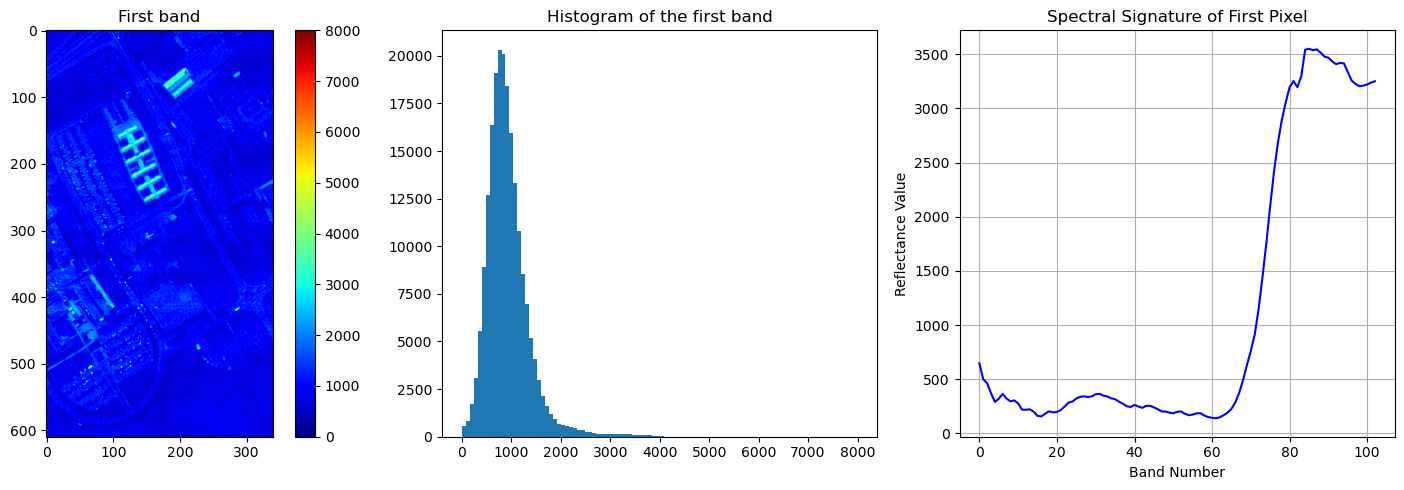

In [193]:
# Loading the data and checking some statistics.

# We can also use other kinds of libraries to load the data such as h5py or mat73, but we will use scipy to load the data.
# loadmat might not work if the data is stored in latest versions of matlab. In that case, we can use h5py or mat73 to load the data. In this case, we will use loadmat to load the data.
pavia_data = loadmat('paviaU.mat') #original data
pavia_gt = loadmat('paviaU_gt.mat') #ground truth

#.mat files are stored in such a way that the variable names are stored as keys in the dictionary. The keys in the dictionary are the variable names and the values are the data stored in the variable. We need to extract the data from the dictionary and store it in a variable.
#Our concern is the data stored in the variable 'paviaU'. We will extract the data from the dictionary and store it in a variable.
print(f"Dataset is stored as a dictionary: {pavia_data.keys()}")
paviaU = pavia_data['paviaU']  # Extracting the data from the dictionary and storing it in a variable.
print(f"Shape of Pavia dataset = {paviaU.shape}")
print(f"Datatype = {paviaU.dtype}")  #The data type is unsigned integer type of 16 bits. This means that the data is stored in the form of 16 bit unsigned integers.
print(f"Is data stored in numpy array? Ans = {isinstance(paviaU, np.ndarray)}")  #isinstance to check the data is numpy array or not
print(f"Class type  = {type(paviaU)}")  #Checking if the data is stored in the form of a numpy array or not.

print("------------------------------------------------------------------------------------------------------------------------------")
#Extracting ground truth
print(f"Ground truth image is also stored as a dictionary: {pavia_gt.keys()}")
paviaU_gt = pavia_gt['paviaU_gt'] # Extract the ground truth data
print(f"Shape of Ground Truth = {paviaU_gt.shape}")

# It means the data is stored in the form of a numpy array.
# Now we can visualize the data and do necessary exploratory data analysis as required.
#print(paviaU[:,:,0])  #Printing the first band of the data.
print("------------------------------------------------------------------------------------------------------------------------------")
print(f"Minimum value in the dataset = {paviaU[:,:,0].min()} and maximum value in the dataset = {paviaU[:,:,0].max()}")  #Printing the minimum and maximum values of the first band of the data.
print(f"Mean of the data = {paviaU[:,:,0].mean()}, Std = {paviaU[:,:,0].std()}")  #Printing the mean and standard deviation of the first band of the data.
#print(paviaU[0,0,:]) #print the first pixel of the data.

# Create a figure with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot the first band of the data
axs[0].imshow(paviaU[:, :, 0], cmap='jet')
axs[0].set_title("First band")
fig.colorbar(axs[0].imshow(paviaU[:, :, 0], cmap='jet'), ax=axs[0])

# Plot the histogram of the first band of the data
axs[1].hist(paviaU[:, :, 0].flatten(), bins=100)
axs[1].set_title('Histogram of the first band')

# Plot the spectral signature of the first pixel
first_pixel = paviaU[0, 0, :]
axs[2].plot(first_pixel, linestyle='-', color='b')
axs[2].set_xlabel('Band Number')
axs[2].set_ylabel('Reflectance Value')
axs[2].set_title('Spectral Signature of First Pixel')
axs[2].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

Blue band: 10, Wavelength: 481.96078431372547 nm
Green band: 23, Wavelength: 549.5098039215686 nm
Red band: 42, Wavelength: 648.2352941176471 nm
Red-edge band: 56, Wavelength: 720.9803921568628 nm
NIR band: 81, Wavelength: 850.8823529411765 nm


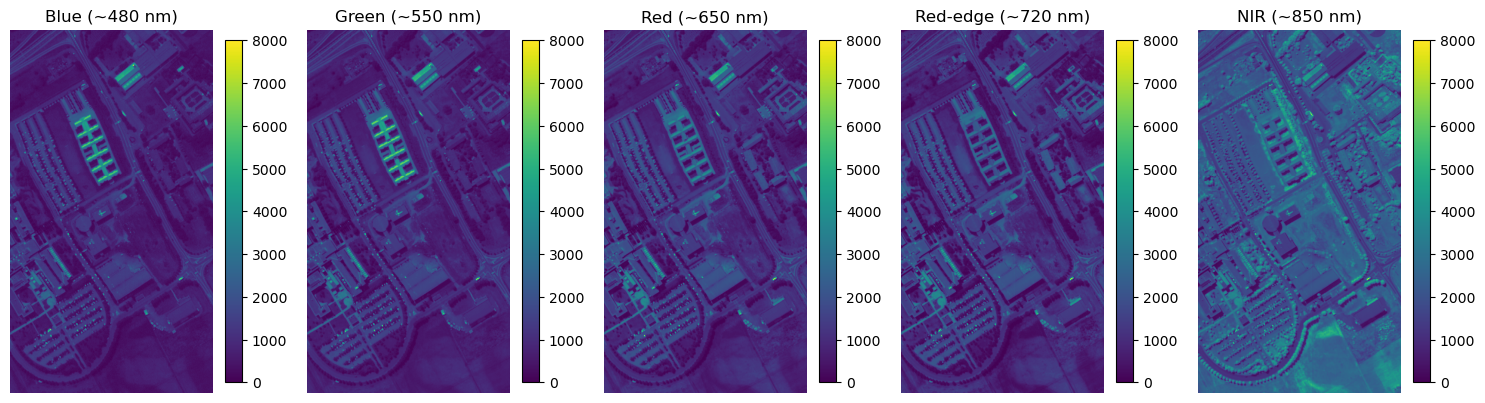

In [34]:
# Select and display five different bands as mentioned.
# Wavelength range and band count: Since it is provided that the sensor captures wavelengths from 430 nm to 960 nm with 103 bands with 5nm spacing.
start_wavelength = 430   # in nm
end_wavelength = 960     # in nm
band_count = 103

# Generate the wavelength values
wavelengths = np.linspace(start_wavelength, end_wavelength, band_count)

# Find the closest bands for each region. Provides Index for each band.
blue_band = np.argmin(np.abs(wavelengths - 480))      # Blue ~480 nm
green_band = np.argmin(np.abs(wavelengths - 550))     # Green ~550 nm
red_band = np.argmin(np.abs(wavelengths - 650))       # Red ~650 nm
red_edge_band = np.argmin(np.abs(wavelengths - 720))  # Red-edge ~720 nm
nir_band = np.argmin(np.abs(wavelengths - 850))       # NIR ~850 nm

print(f"Blue band: {blue_band}, Wavelength: {wavelengths[blue_band]} nm")
print(f"Green band: {green_band}, Wavelength: {wavelengths[green_band]} nm")
print(f"Red band: {red_band}, Wavelength: {wavelengths[red_band]} nm")
print(f"Red-edge band: {red_edge_band}, Wavelength: {wavelengths[red_edge_band]} nm")
print(f"NIR band: {nir_band}, Wavelength: {wavelengths[nir_band]} nm")

# Extract bands
blue = paviaU[:, :, blue_band]
green = paviaU[:, :, green_band]
red = paviaU[:, :, red_band]
red_edge = paviaU[:, :, red_edge_band]
nir = paviaU[:, :, nir_band]

# Plot each band
bands = [blue, green, red, red_edge, nir]
titles = ['Blue (~480 nm)', 'Green (~550 nm)', 'Red (~650 nm)', 'Red-edge (~720 nm)', 'NIR (~850 nm)']

plt.figure(figsize=(15, 6))
for i, band in enumerate(bands):
    plt.subplot(1, 5, i + 1)
    plt.imshow(band)
    plt.colorbar(shrink = 0.6)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


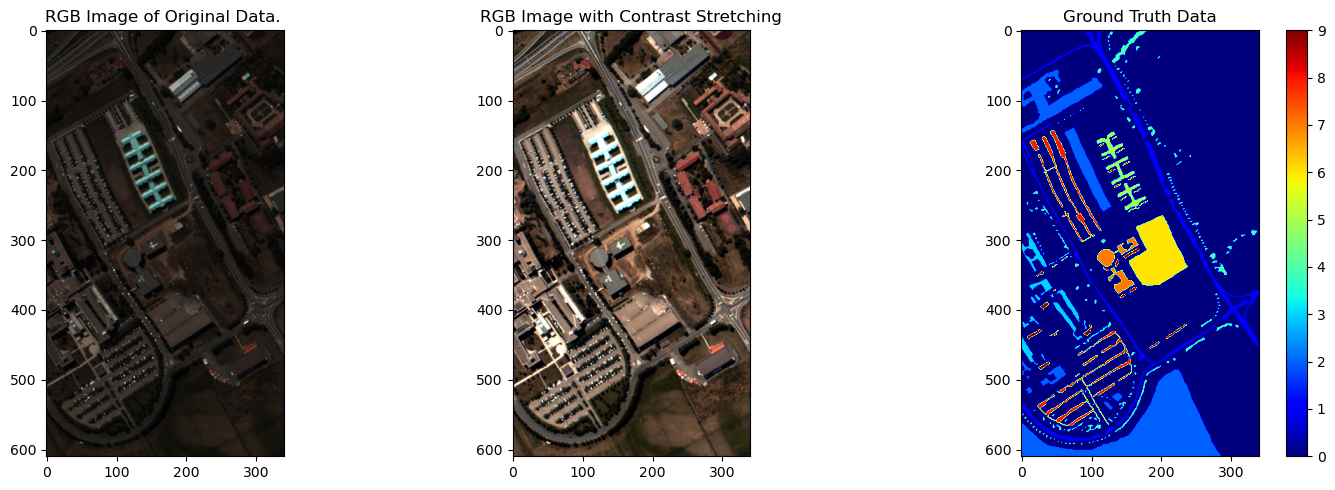

In [47]:
#Display RGB image and ground truth data.

# Function to display RGB image
def display_rgb_image_with_contrast_stretching(image, pmin=2, pmax=98):
    """Display RGB image from hyperspectral data."""
    blue = image[:,:,10]
    green = image[:,:,23]
    red = image[:,:,42]
    rgb_image = np.stack((red, green, blue), axis=2)

    min_val = np.percentile(rgb_image, pmin)  # Compute 2nd percentile
    max_val = np.percentile(rgb_image, pmax)  # Compute 98th percentile

    stretched = (rgb_image- min_val) / (max_val - min_val)  # Normalize
    stretched = np.clip(stretched, 0, 1)  # Clip values to [0,1] range

    return stretched

# Display RGB image.
rgb_image = np.stack((red, green, blue), axis=2)
# Normalize to 0-1 range
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

# Create a figure with 1 row and 3 columns
plt.figure(figsize=(15, 5))  # Adjust figure size for better visualization

# Plot 1: Display the RGB image
plt.subplot(1, 3, 1)  # 1 row, 3 columns, 1st subplot
plt.imshow(rgb_image)
plt.title('RGB Image of Original Data. ')

# Plot 2: Display the RGB image with contrast stretching
plt.subplot(1, 3, 2)  # 1 row, 3 columns, 2nd subplot
stretched_image = display_rgb_image_with_contrast_stretching(paviaU)  # Get the stretched image
plt.imshow(stretched_image)
plt.title('RGB Image with Contrast Stretching')

# Plot 3: Display the ground truth data
plt.subplot(1, 3, 3)  # 1 row, 3 columns, 3rd subplot
plt.imshow(paviaU_gt, cmap='jet')
plt.colorbar(shrink=1)  # Add a colorbar and shrink it
plt.title('Ground Truth Data')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


In [60]:
# Check if there are no data or shadow pixels.
# Create a mask for pixels that are not entirely 0
mask = np.any(paviaU !=0, axis=-1) #Shape = (height, width)  #Creates a boolean mask : True if entire pixel is non zero, False if entire pixel has 0 values.

# Check if there are any False values.
if np.any(~mask):
    print("The mask has False values.")
else:
    print("There are no False values in the mask.")

# Since, we obtained False, there are no such pixels with entire 0 values, so we don't need to account for such data points.

There are no False values in the mask.


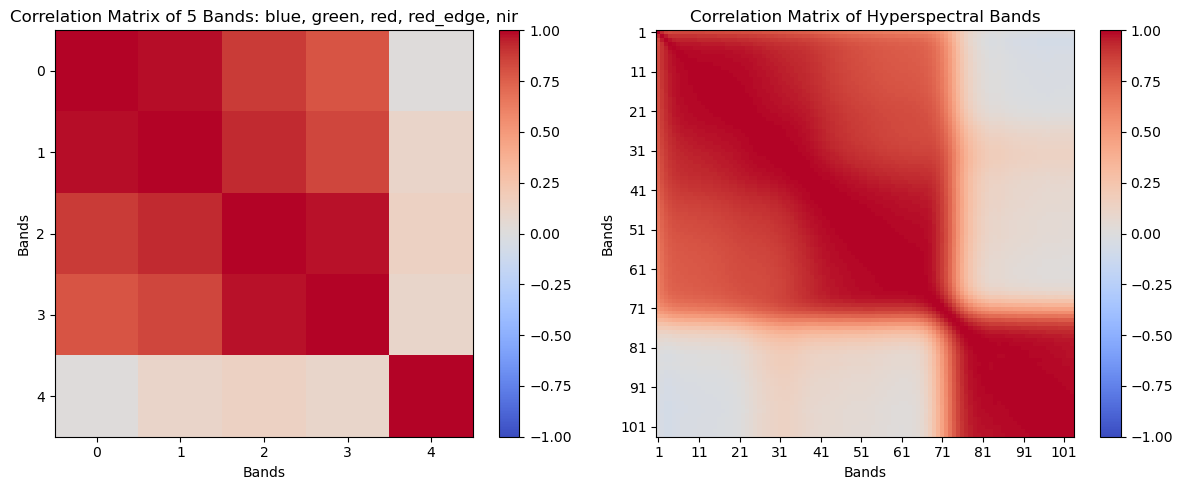

In [187]:
# Visualize correlation among all bands and among selected 5 bands.

# Reshape the data to 2D (pixels x bands)
height, width, bands = paviaU.shape
paviaU_2d = paviaU.reshape(-1, bands) # Shape = (height x width, bands)

# Compute the correlation matrix.
correlation_matrix = np.corrcoef(paviaU_2d, rowvar = False) # Shape = (bands, bands), rowvar = False indicates each column represents band and row represents pixel.
# Note: If there are nan values in numpy array, np.corrcoef doesn't work, in such cases, convert the 2d data into pandas dataframe and use df.corr()

# Select only 5 bands as mentioned in the question for further processing.
paviaU_5bands = paviaU[:,:,[blue_band, green_band, red_band, red_edge_band, nir_band]]  # use indexes for five bands to extract only those bands for further processing.
corr_matrix_5bands = np.corrcoef(paviaU_5bands.reshape(-1,paviaU_5bands[0,0,:].size), rowvar= False)

# Create a figure with two subplots in one row and two columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot the first correlation matrix (5 bands)
im1 = axes[0].imshow(corr_matrix_5bands, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlation Matrix of 5 Bands: blue, green, red, red_edge, nir')
axes[0].set_xlabel('Bands')
axes[0].set_ylabel('Bands')
fig.colorbar(im1, ax=axes[0])  # Add colorbar to the first subplot

# Plot the second correlation matrix (103 bands)
im2 = axes[1].imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('Correlation Matrix of Hyperspectral Bands')
axes[1].set_xlabel('Bands')
axes[1].set_ylabel('Bands')
axes[1].set_xticks(ticks=np.arange(0, 103, 10), labels=np.arange(1, 104, 10))  # Custom x-ticks
axes[1].set_yticks(ticks=np.arange(0, 103, 10), labels=np.arange(1, 104, 10))  # Custom y-ticks
fig.colorbar(im2, ax=axes[1])  # Add colorbar to the second subplot

# Adjust layout and display the figure
plt.tight_layout()
plt.show()


Number of samples in each class (including class 0): 207400
Class 0: 164624 samples
Class 1: 6631 samples
Class 2: 18649 samples
Class 3: 2099 samples
Class 4: 3064 samples
Class 5: 1345 samples
Class 6: 5029 samples
Class 7: 1330 samples
Class 8: 3682 samples
Class 9: 947 samples

Number of samples in each class (excluding class 0): 42776
Class 1: 6631 samples
Class 2: 18649 samples
Class 3: 2099 samples
Class 4: 3064 samples
Class 5: 1345 samples
Class 6: 5029 samples
Class 7: 1330 samples
Class 8: 3682 samples
Class 9: 947 samples


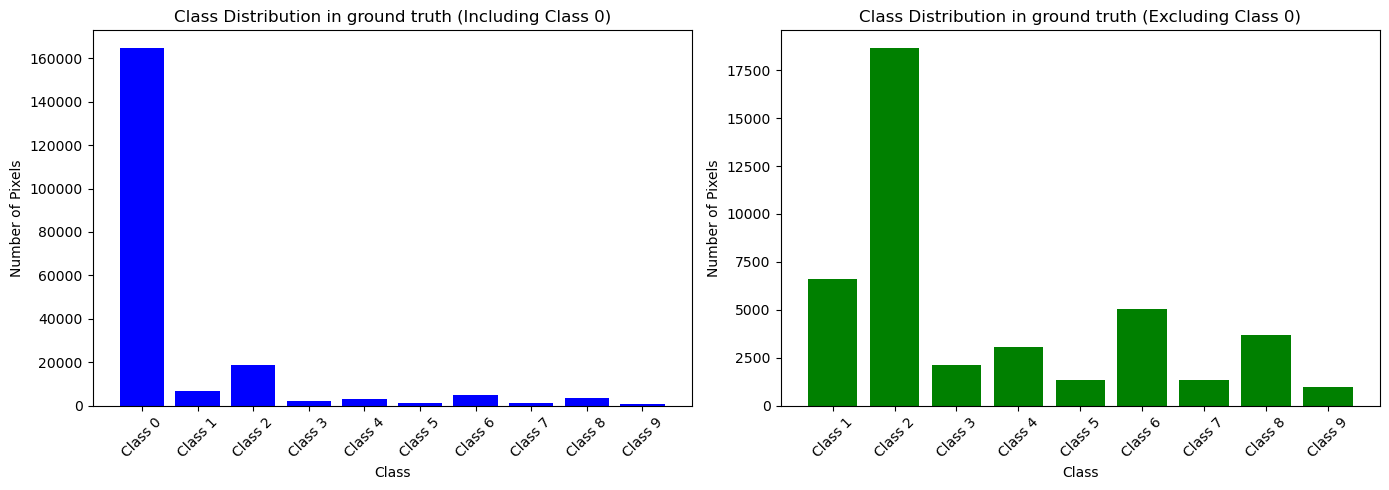

In [194]:
# Visualize the class distribution in ground truth data or class map.

# Flatten the ground truth labels
ground_truth = paviaU_gt.flatten()

# Count the number of pixels in each class (including class 0)
class_counts_before = np.bincount(ground_truth)

# Print the number of samples in each class (including class 0)
print(f"Number of samples in each class (including class 0): {np.sum(class_counts_before)}")
for class_label, count in enumerate(class_counts_before):
    print(f"Class {class_label}: {count} samples")

# Ignore class 0
mask = ground_truth != 0
ground_truth_filtered = ground_truth[mask]

# Count the number of pixels in each class (excluding class 0)
class_counts_after = np.bincount(ground_truth_filtered)

# Print the number of samples in each class (excluding class 0)
print(f"\nNumber of samples in each class (excluding class 0): {np.sum(class_counts_after)}")
for class_label, count in enumerate(class_counts_after):
    if class_label == 0:
        continue  # Skip class 0
    print(f"Class {class_label}: {count} samples")

# Class labels (0-9)
class_labels = [f'Class {i}' for i in range(10)]

# Create a figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the class distribution before ignoring class 0
axes[0].bar(class_labels, class_counts_before, color='blue')
axes[0].set_title('Class Distribution in ground truth (Including Class 0)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Pixels')
axes[0].tick_params(axis='x', rotation=45)

# Plot the class distribution after ignoring class 0
axes[1].bar(class_labels[1:], class_counts_after[1:], color='green')  # Exclude class 0
axes[1].set_title('Class Distribution in ground truth (Excluding Class 0)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Pixels')
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout and display the figure
plt.tight_layout()
plt.show()

In [196]:
# Note: Use another approach below after this cell: Here we are selecting equal number of samples (equal to class 9) from all classes and then dividing into veg vs non veg class. It results in unbalanced veg-nonveg class. So, better prefer next way below, where we use balanced veg and nonveg class. Veg = from class 2 and 4, samples = 947x2. Nonveg = (947x2) where (947x2)/7 form each remaining 7 classes.

# X = paviaU_5bands.reshape(-1,paviaU_5bands[0,0,:].size) # Convert the data into 2d
# y = paviaU_gt.flatten() # Flatten ground truth labels.
#
# # Ignore class 0 in labels (ublabeled data) .
# mask  = y != 0
# X = X[mask]   # shapes the data to (42776, 5)
# y = y[mask]   # shapes the data to (42776), now y has class values [1 2 3 4 5 6 7 8 9]
#
# # Ensure equal representation of classes 1-9 in train and test sets
# from sklearn.utils import resample
#
# # Create a balanced dataset by undersampling the majority classes
#
# # Get unique class labels and their counts
# unique_classes, class_counts = np.unique(y, return_counts=True)
# # Calculate the minimum class size
# min_class_size = min(class_counts)  #947 which is the class 9.
#
# X_balanced = []
# y_balanced = []
#
# for class_label in np.unique(y):
#     X_class = X[y == class_label]
#     y_class = y[y == class_label]
#     X_resampled, y_resampled = resample(X_class, y_class, n_samples=min_class_size, random_state=42)
#     X_balanced.append(X_resampled)
#     y_balanced.append(y_resampled)
#
# X = np.vstack(X_balanced)  # shape (8523, 5)
# y = np.hstack(y_balanced)  # shape (8523,)
#
# # Map classes to vegetation (1) and non-vegetation (0)
# # Vegetation includes classes for trees and meadows (class 2 and 4)
# vegetation_classes = [2, 4]
# y = np.where(np.isin(y, vegetation_classes), 1, 0) # assign 1 if element in y belongs to vegetation class else assign 0. Here, np.isin assigns True or False. np.where assigns 1 to Ture and 0 to False.
#
# # Train/test split (70% training, 30% testing)
# # Stratified sampling ensures class proportions (0 and 1) remain the same in train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


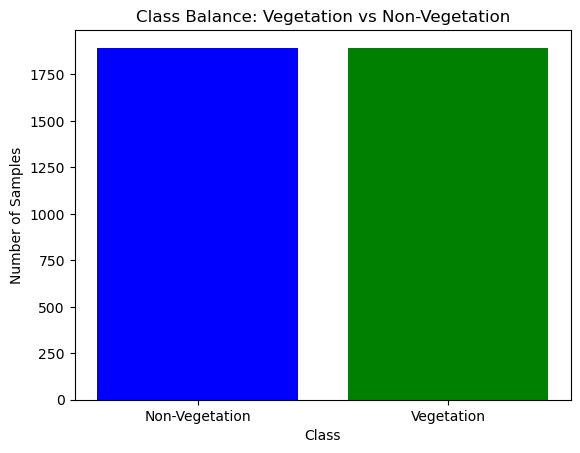

In [207]:
# Balance vegetation and non-vegetation pixels before using logistic regression.

# Reshape and flatten the data
X = paviaU_5bands.reshape(-1, paviaU_5bands[0, 0, :].size)  # Convert the data into 2D
y = paviaU_gt.flatten()  # Flatten ground truth labels

# Ignore class 0 in labels (unlabeled data)
mask = y != 0
X = X[mask]  # Shapes the data to (42776, 5)
y = y[mask]  # Shapes the data to (42776), now y has class values [1 2 3 4 5 6 7 8 9]

# Ensure equal representation of classes 1-9 in train and test sets
unique_classes, class_counts = np.unique(y, return_counts=True)
min_class_size = min(class_counts)  # 947 (class 9)

# Define vegetation and non-vegetation classes
vegetation_classes = [2, 4]
non_vegetation_classes = [1, 3, 5, 6, 7, 8, 9]

# Calculate the number of samples to take from each non-vegetation class
n_samples_non_vegetation = (min_class_size * 2) // len(non_vegetation_classes)  # 271 samples per class

# Create balanced datasets for vegetation and non-vegetation
X_balanced = []
y_balanced = []

# Sample vegetation classes
for class_label in vegetation_classes:
    X_class = X[y == class_label]
    y_class = y[y == class_label]
    X_resampled, y_resampled = resample(X_class, y_class, n_samples=min_class_size, random_state=42)
    X_balanced.append(X_resampled)
    y_balanced.append(y_resampled)

# Sample non-vegetation classes
for class_label in non_vegetation_classes:
    X_class = X[y == class_label]
    y_class = y[y == class_label]
    X_resampled, y_resampled = resample(X_class, y_class, n_samples=n_samples_non_vegetation, random_state=42)
    X_balanced.append(X_resampled)
    y_balanced.append(y_resampled)

# Combine the balanced datasets
X = np.vstack(X_balanced)  # Shape: (1894 + 1897, 5) = (3791, 5)
y = np.hstack(y_balanced)  # Shape: (3791,)

# Map classes to vegetation (1) and non-vegetation (0)
y = np.where(np.isin(y, vegetation_classes), 1, 0)

# Count the number of samples for each class
class_counts = np.bincount(y)  # y contains 0 (non-vegetation) and 1 (vegetation)

# Class labels
class_labels = ['Non-Vegetation', 'Vegetation']

# Plot the bar chart
plt.bar(class_labels, class_counts, color=['blue', 'green'])
plt.title('Class Balance: Vegetation vs Non-Vegetation')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()



Training Performance:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      1323
           1       0.90      0.96      0.93      1325

    accuracy                           0.93      2648
   macro avg       0.93      0.93      0.93      2648
weighted avg       0.93      0.93      0.93      2648

Testing Performance:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       567
           1       0.90      0.97      0.94       569

    accuracy                           0.93      1136
   macro avg       0.94      0.93      0.93      1136
weighted avg       0.94      0.93      0.93      1136

Mean training accuracy: 0.93
Mean testing accuracy: 0.93
Mean per-class accuracy: 0.93
Mean Precision: 0.94
Mean Recall: 0.93
Mean F1-Score: 0.93


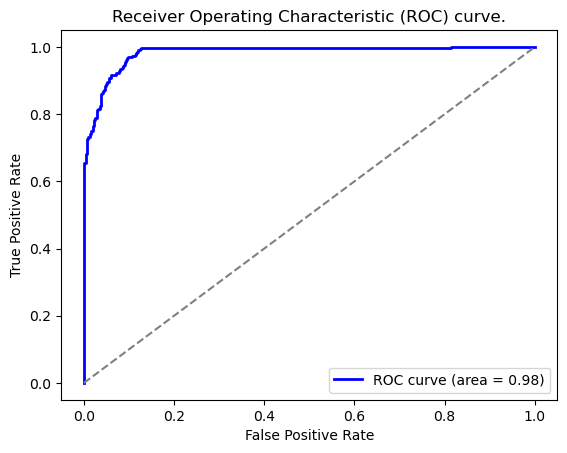

Area Under the Curve (AUC): 0.98


In [208]:
#Perform binary classification using logistic regression to distinguish vegetation and non-vegetation pixels.
# Display evaluation metrics and ROC curve.

# Train/test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Standardize features: zero mean and unit variance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  #fit_transform calculates mean and std and applies to transform the data (standardize)
X_test = scaler.transform(X_test) #transform uses same mean and std calculate earlier to transform the data

# Note: Standardization is not necessary in this case. Results didn't make much difference with and without standardization.

# Train logistic regression model
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Predictions on training and testing sets
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Evaluation metrics: accuracy, precision, recall, F1-score
print("Training Performance:")
print(classification_report(y_train, y_train_pred))

print("Testing Performance:")
print(classification_report(y_test, y_test_pred))

# Mean accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Mean training accuracy: {train_accuracy:.2f}")
print(f"Mean testing accuracy: {test_accuracy:.2f}")

# Mean per-class accuracy
conf_matrix = confusion_matrix(y_test, y_test_pred)
class_accuracies = conf_matrix.diagonal() / conf_matrix.sum(axis=1)
mean_per_class_accuracy = class_accuracies.mean()
print(f"Mean per-class accuracy: {mean_per_class_accuracy:.2f}")

# Mean precision, recall, and F1-score
mean_precision = precision_score(y_test, y_test_pred, average='macro')
mean_recall = recall_score(y_test, y_test_pred, average='macro')
mean_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Mean Precision: {mean_precision:.2f}")
print(f"Mean Recall: {mean_recall:.2f}")
print(f"Mean F1-Score: {mean_f1:.2f}")

# Get predicted probabilities for the positive class (vegetation)
y_test_prob = lr.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve.')
plt.legend(loc='lower right')
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.2f}")


### **Comments: 1. a. and b.:**
The dataset is a hyperspectral image of Pavia University, Italy. It has 103 bands and the spatial resolution is 610x340 pixels. The ground truth data is also provided which contains the class labels for each pixel in the image. The classes are as follows:
- 0. Unlabled
- 1. Asphalt
- 2. Meadows
- 3. Gravel
- 4. Trees
- 5. Painted metal sheets
- 6. Bare Soil
- 7. Bitumen
- 8. Self-Blocking Bricks
- 9. Shadows

### Pre Processing

 Visualizing the dataset , it was observed that the pixel values are in digital counts. So, in such cases, it is recommended to either normalize or standardize the data. However, in our case, the results of logistic regression didn't result in much difference with or without standardization. In preprocessing steps, it is important to check if the dataset has 'no data' or  '0' values, which usually represents shadows in hyperspectral images. They can alter or skew the distribution. An easy way to analyze such points is to check if the entire pixel after reshaping the data in 2D has all 0 values. In such cases, creating a mask or handling using 'nan' operation is recommended. It was not the case in this problem. For hyperspectral images, with large number of bands, it is also important to observe correlation among various bands. In the provided data, first 72 bands and bands from 75-103 were highly correlated with each other. The fist 72 bands with the later bands didn't show any correlation or very minimal negative correlation with each other.  In highly correlated bands, we can ignore or remove such bands and can only take few bands from them for further processing as the information in such bands is usually redundant. Another way is to do dimensionality reduction using techniques like PCA, LDA, etc. before classification or further processing. Only a subset of bands (5 bands) blue, green, red, red_edge and nir were selected and used for logistic regression. In 5 band data, first 4 bands were positively correlated with each other but no correlation was seen among bands 0-3 vs band 4.Even among first four bands, band 0-1 and 2-3 were highly correlated.

### Data Visualization and Solving Imbalance Problem

There were 9 number of classes in the data which were highly imbalanced. Class 0 (unlabeled) class was removed before processing. To ensure balanced distribution of each 9 classes in train - test samples, undersampling was performed in two stages. A class with minimum number of samples (class 9: 947 samples) was detected and 947 samples were randomly drawn from each class. The resulting number of samples were 8523, which could be split into train to test percentage ratio as 70:30 or 80:20. But doing so, would result in unbalanced class distribution of vegetation vs non vegetation samples. So, we used approach as described in Case 2 below:

### Case 1: Equal Samples from All Classes (Unbalanced Vegetation vs Non-Vegetation)

In this approach, we ensure that each of the 9 classes (excluding class 0, which represents unlabeled data) has an equal number of samples. Here's how it works:

1. **Class Distribution:**
   - There are 9 classes in the dataset (classes 1 to 9), which are highly imbalanced.
   - Class 0 (unlabeled) is removed before processing.

2. **Undersampling:**
   - The class with the minimum number of samples (class 9: 947 samples) is identified.
   - To ensure equal representation, **947 samples are randomly drawn from each of the 9 classes**.
   - This results in a total of \( 947 \times 9 = 8523 \) samples.

3. **Vegetation vs Non-Vegetation Mapping:**
   - Vegetation is defined as classes 2 and 4.
   - Non-vegetation is defined as the remaining 7 classes (1, 3, 5, 6, 7, 8, 9).
   - After mapping:
     - Vegetation: \( 947 \times 2 = 1894 \) samples.
     - Non-vegetation: \( 947 \times 7 = 6629 \) samples.

4. **Issue with This Approach:**
   - While the original 9 classes are balanced, the resulting **vegetation vs non-vegetation classes are highly imbalanced**.
   - Vegetation has 1894 samples, while non-vegetation has 6629 samples.
   - This imbalance can bias the model toward the majority class (non-vegetation).

---

### Case 2: Balanced Vegetation vs Non-Vegetation Classes

To address the imbalance between vegetation and non-vegetation classes, a second approach is used. Here's how it works:

1. **Vegetation Samples:**
   - Vegetation is defined as classes 2 and 4.
   - Each vegetation class contributes **947 samples**, resulting in \( 947 \times 2 = 1894 \) vegetation samples.

2. **Non-Vegetation Samples:**
   - Non-vegetation is defined as the remaining 7 classes (1, 3, 5, 6, 7, 8, 9).
   - To balance the dataset, each non-vegetation class contributes \( \frac{1894}{7} \approx 271 \) samples.
   - This results in \( 271 \times 7 = 1897 \) non-vegetation samples.

3. **Total Samples:**
   - Vegetation: 1894 samples.
   - Non-vegetation: 1897 samples.
   - Total: \( 1894 + 1897 = 3791 \) samples.

4. **Advantages of This Approach:**
   - The **vegetation and non-vegetation classes are balanced**, ensuring that the model is not biased toward either class.
   - This approach is more suitable for training a model that needs to perform well on both vegetation and non-vegetation classes.

---

### Difference in Results of unbalanced vs balanced class distribution in Vegetation and Non-vegetaion samples.

![Veg-Nonveg unbalanced_class_distribution](veg_nonveg_unbalanced.png) ![Veg-nonveg balanced class distribution](veg_nonveg_balanced.png)
![Veg-Nonveg unbalanced_class_distribution_results](veg_nonveg_unbalanced_results.png) ![Veg-Nonveg balanced_class_distribution_results](veg_nonveg_balanced_results.png)

### Analysis based on Case 2:

It is observed that, in the provided dataset, Case 1 and Case 2 didn't result in much different results. However it is important to follow approach of Case 2 for imbalanced and complex dataset. The evaluation metrics like mean accuracy and mean per-class accuracy, precision, recall, and F1-score were reported. For class 0 (non vegetation), precision of 0.96 implies that out of all predicted samples as non vegetation 96% were correct. It means 4% of the predicted samples were incorrect. 0.90 recall means 90% of total non vegetation pixels were correctly identified by the model. It means model missed 10% of non vegetation pixels. F1-score is a balanced measure of precision and recall for each class. A higher F1-score means the model is performing very well. Similarly, the results for vegetation (class 1) can also be interpreted. In both classes, the model produced higher values for these metrics. The macro average of precision, recall and F1-score is computed treating each class equally while the weighted average is weighted by the number of samples in each class. The macro and weighted average also indicate about the class imbalance. If both are equal, it means the data has balanced classes and vice versa. In our case, since we have balanced veg and non veg class, both metrics are same. The ROC curve is a graphical representation of a classification model's performance across all classification thresholds. It is a plot between true positive rate vs false positive rate. The area under curve (AUC) indicates model's discriminative power. It provides a single scalar value to summarize the model's performance across all classification thresholds. AUC of 0.5(diagonal line) represents a random classifier i.e., no discriminative power. AUC > 0.5 represents better classifier and AUC =1 represents a perfect classifier. In our case, AUC = 0.98 indicates a very good classifier. In both training and testing, the model produced similar values above 90% or higher indicating the strong performance. Also, since the training and testing metrics are similar, it implies that the model didn't overfit.

#### References:
- https://www.mariakhalusova.com/posts/2019-04-17-ml-model-evaluation-metrics-p2/#:~:text=Macro%2Daveraged%3A%20all%20classes%20equally,is%20weighted%20by%20its%20size
- https://datascience.stackexchange.com/questions/65839/macro-average-and-weighted-average-meaning-in-classification-report

### Extra Notes on Standardization and Dimensionality Reduction:
- Why not min max normalization?
- Min-max normalization scales the data to a fixed range, typically [0, 1]. This can be problematic if the data has outliers or if the distribution is not uniform.
- For SVM or PCA: Standardization is usually better. It centers the data around 0 and scales it based on the standard deviation, making it more robust to outliers.
- For Neural Networks, kNN: Min-max normalization is often preferred.

- Correlation Heatmap:
As seen in the correlation matrix of the data, there are some bands that are highly correlated with each other. This means that these bands carry similar information. So, we can remove some of the bands that are highly correlated with each other to reduce the dimensionality of the data. This will also help in reducing the computational cost and memory requirements.

For hyperspectral image classification tasks like the Pavia University dataset, removing highly correlated bands or reducing dimensionality is often a crucial preprocessing step. This is because hyperspectral data typically contains hundreds of spectral bands, many of which are highly correlated and redundant. These redundancies can lead to increased computational complexity, overfitting, and reduced classification performance.

In such case, we can proceed with the following steps:
1. **Correlation Analysis**: Calculate the correlation matrix of the hyperspectral data to identify highly correlated bands.
2. **Band Selection**: Remove bands that are highly correlated (e.g., correlation coefficient > 0.9) to reduce redundancy.
3. **Dimensionality Reduction**: Apply techniques like PCA, t-SNE, LDA, etc.  to further reduce the dimensionality while retaining most of the variance in the data.
4. **Feature Selection**: (haven't discussed yet in course) Use feature selection methods to identify the most informative bands for classification.
5. **Model Training**: Train the classification model on the reduced set of bands.
6. **Evaluation**: Evaluate the model's performance using metrics like accuracy, F1-score, and confusion matrix.
7. **Visualization**: Visualize the classification results to understand the model's performance and identify areas for improvement.
8. **Iterative Refinement**: Based on the evaluation, iteratively refine the band selection and preprocessing steps to optimize classification performance.



#### Problem 1.c. : Multiclass classification using XG boost.

In [209]:
pip install xgboost


   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   - -------------------------------------- 3.9/124.9 MB 26.0 MB/s eta 0:00:05
   --- ------------------------------------ 10.5/124.9 MB 29.7 MB/s eta 0:00:04
   ----- ---------------------------------- 17.3/124.9 MB 31.2 MB/s eta 0:00:04
   ------- -------------------------------- 23.3/124.9 MB 31.4 MB/s eta 0:00:04
   -------- ------------------------------- 27.8/124.9 MB 28.9 MB/s eta 0:00:04
   ---------- ----------------------------- 32.8/124.9 MB 28.1 MB/s eta 0:00:04
   ----------- ---------------------------- 37.2/124.9 MB 26.9 MB/s eta 0:00:04
   ------------ --------------------------- 40.4/124.9 MB 25.4 MB/s eta 0:00:04
   -------------- ------------------------- 45.9/124.9 MB 25.6 MB/s eta 0:00:04
   ---------------- ----------------------- 50.9/124.9 MB 25.5 MB/s eta 0:00:03
   ------------------ --------------------- 56.4/124.9 MB 25.5 MB/s eta 0:00:03
   -------------------- ------------------- 63.2/

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       567
           1       0.93      0.98      0.95       569

    accuracy                           0.95      1136
   macro avg       0.95      0.95      0.95      1136
weighted avg       0.95      0.95      0.95      1136

Confusion Matrix:
[[527  40]
 [ 14 555]]
Accuracy: 0.9524647887323944
ROC AUC Score: 0.9901680909296611


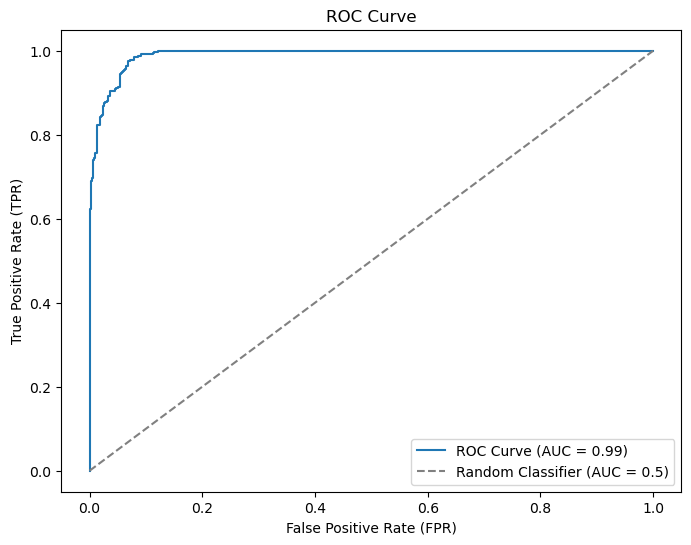

In [210]:
#----
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 1: Convert the dataset into DMatrix (XGBoost's optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Step 2: Set XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',        # Logarithmic loss for evaluation
    'max_depth': 6,                  # Maximum depth of a tree
    'eta': 0.1,                      # Learning rate
    'subsample': 0.8,                # Subsample ratio of the training instances
    'colsample_bytree': 0.8,         # Subsample ratio of columns when constructing each tree
    'seed': 42                       # Random seed for reproducibility
}

# Step 3: Train the model
num_rounds = 100  # Number of boosting rounds
model = xgb.train(params, dtrain, num_rounds)

# Step 4: Make predictions on the test set
y_pred_prob = model.predict(dtest)  # Predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions (0 or 1)

# Step 5: Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Step 6: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for balanced data')
plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

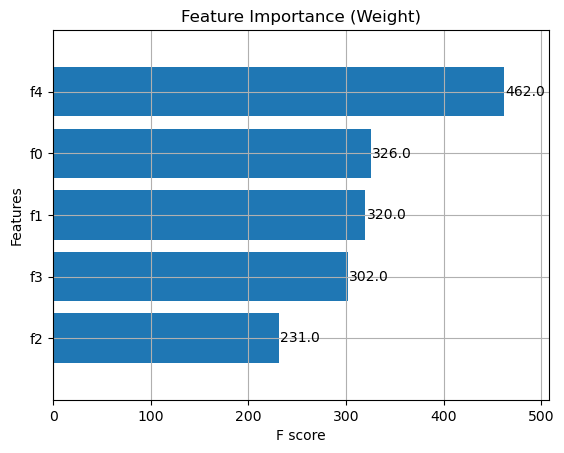

In [211]:
# Plot feature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Feature Importance (Weight)')
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1989
           1       0.84      0.97      0.90      5595
           2       0.75      0.68      0.71       630
           3       0.91      0.86      0.88       919
           4       0.99      0.99      0.99       403
           5       0.83      0.40      0.54      1509
           6       0.79      0.80      0.80       399
           7       0.79      0.86      0.82      1105
           8       1.00      1.00      1.00       284

    accuracy                           0.85     12833
   macro avg       0.87      0.83      0.84     12833
weighted avg       0.85      0.85      0.84     12833

Confusion Matrix:
[[1769    5   37    0    3   11   79   85    0]
 [   1 5414    0   74    0  103    0    3    0]
 [  44    2  426    0    0    1    0  157    0]
 [   0  132    0  786    0    1    0    0    0]
 [   0    0    0    0  400    2    0    1    0]
 [   3  885   

<Figure size 1000x600 with 0 Axes>

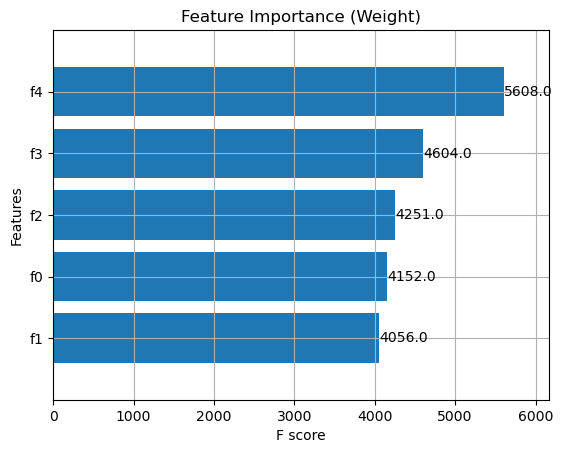

In [219]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

# Reshape and flatten the data
X_un = paviaU_5bands.reshape(-1, paviaU_5bands[0, 0, :].size)  # Convert the data into 2D
y_un = paviaU_gt.flatten()  # Flatten ground truth labels

# Ignore class 0 in labels (unlabeled data)
mask_un = y_un != 0
X_un = X_un[mask_un]  # Shapes the data to (42776, 5)
y_un = y_un[mask_un]  # Shapes the data to (42776), now y has class values [1 2 3 4 5 6 7 8 9]

# Convert labels to zero-indexed format
y_un = y_un - 1  # Now y_un has class values [0 1 2 3 4 5 6 7 8]

# Train/test split (70% training, 30% testing)
X_train_un, X_test_un, y_train_un, y_test_un = train_test_split(X_un, y_un, test_size=0.3, stratify=y_un, random_state=42)

# Step 1: Convert the dataset into DMatrix (XGBoost's optimized data structure)
dtrain_un = xgb.DMatrix(X_train_un, label=y_train_un)
dtest_un = xgb.DMatrix(X_test_un, label=y_test_un)

# Step 2: Set XGBoost parameters for multi-class classification
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': 9,                # Number of classes
    'eval_metric': 'mlogloss',     # Multi-class log loss for evaluation
    'max_depth': 6,                # Maximum depth of a tree
    'eta': 0.1,                    # Learning rate
    'subsample': 0.8,              # Subsample ratio of the training instances
    'colsample_bytree': 0.8,       # Subsample ratio of columns when constructing each tree
    'seed': 42                     # Random seed for reproducibility
}

# Step 3: Train the model
num_rounds = 100  # Number of boosting rounds
model_un = xgb.train(params, dtrain_un, num_rounds)

# Step 4: Make predictions on the test set
y_pred_un = model_un.predict(dtest_un)  # Predicted class labels

# Step 5: Evaluate the model
print("Classification Report:")
print(classification_report(y_test_un, y_pred_un))

print("Confusion Matrix:")
print(confusion_matrix(y_test_un, y_pred_un))

print("Accuracy:", accuracy_score(y_test_un, y_pred_un))

# Step 6: Plot feature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_un, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Feature Importance (Weight)')
plt.show()

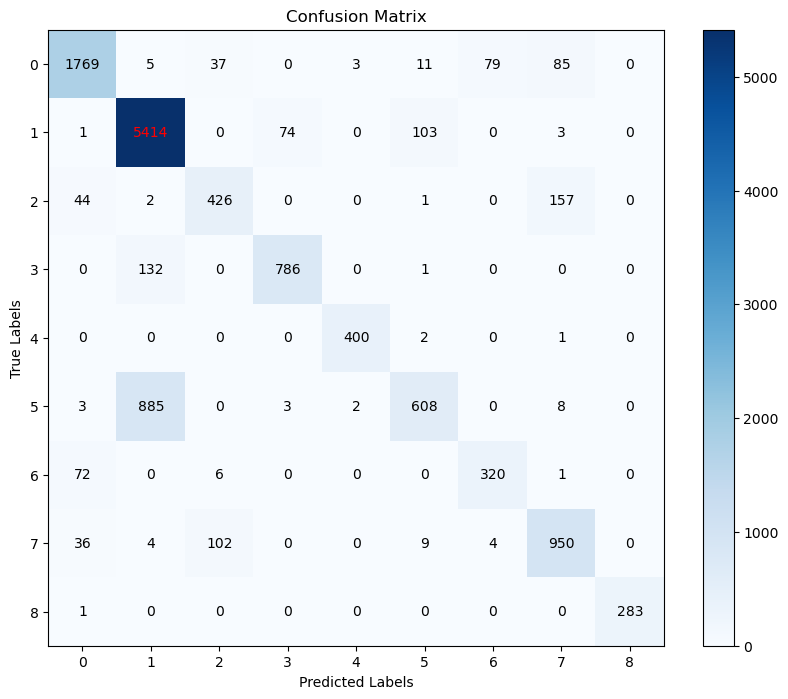

In [228]:

# Image of confusion matrix.
conf_matrix = confusion_matrix(y_test_un, y_pred_un)

# Plot the confusion matrix using plt
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

# Add annotations
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]),
                 horizontalalignment='center',
                 verticalalignment='center',
                 color='red' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black')

# Customize the plot
plt.xticks(np.arange(len(np.unique(y_test_un))), np.unique(y_test_un))
plt.yticks(np.arange(len(np.unique(y_test_un))), np.unique(y_test_un))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       284
           1       0.67      0.68      0.67       284
           2       0.80      0.86      0.83       284
           3       0.95      0.94      0.94       284
           4       1.00      1.00      1.00       284
           5       0.71      0.71      0.71       284
           6       0.89      0.95      0.92       285
           7       0.84      0.80      0.82       284
           8       1.00      1.00      1.00       284

    accuracy                           0.86      2557
   macro avg       0.86      0.86      0.86      2557
weighted avg       0.86      0.86      0.86      2557

Confusion Matrix:
[[230   0  11   0   0   3  28  12   0]
 [  0 192   0  14   0  77   0   1   0]
 [  5   1 245   0   0   0   5  28   0]
 [  0  15   0 266   0   3   0   0   0]
 [  0   0   0   0 284   0   0   0   0]
 [  1  78   0   0   1 203   0   1   0]
 [ 12   0   2   0   

<Figure size 1000x600 with 0 Axes>

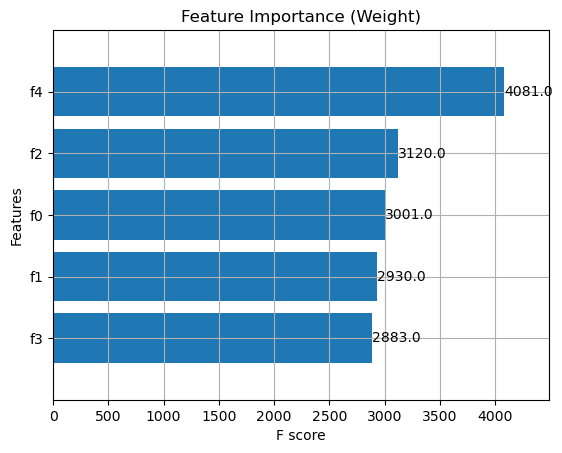

In [220]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np

# Reshape and flatten the data
X_blnc = paviaU_5bands.reshape(-1, paviaU_5bands[0, 0, :].size)  # Convert the data into 2D
y_blnc = paviaU_gt.flatten()  # Flatten ground truth labels

# Ignore class 0 in labels (unlabeled data)
mask_blnc = y_blnc != 0
X_blnc = X_blnc[mask_blnc]  # Shapes the data to (42776, 5)
y_blnc = y_blnc[mask_blnc]  # Shapes the data to (42776), now y has class values [1 2 3 4 5 6 7 8 9]

# Convert labels to zero-indexed format
y_blnc = y_blnc - 1  # Now y_blnc has class values [0 1 2 3 4 5 6 7 8]

# Balance the dataset by undersampling
# Find the number of samples in the least frequent class (class 9)
min_class_size = np.bincount(y_blnc)[-1]  # Number of samples in class 8 (original class 9)

# Create a balanced dataset
X_balanced = []
y_balanced = []

for class_label in np.unique(y_blnc):
    X_class = X_blnc[y_blnc == class_label]
    y_class = y_blnc[y_blnc == class_label]
    X_resampled, y_resampled = resample(X_class, y_class, n_samples=min_class_size, random_state=42)
    X_balanced.append(X_resampled)
    y_balanced.append(y_resampled)

# Combine the balanced datasets
X_blnc = np.vstack(X_balanced)
y_blnc = np.hstack(y_balanced)

# Train/test split (70% training, 30% testing)
X_train_blnc, X_test_blnc, y_train_blnc, y_test_blnc = train_test_split(X_blnc, y_blnc, test_size=0.3, stratify=y_blnc, random_state=42)

# Step 1: Convert the dataset into DMatrix (XGBoost's optimized data structure)
dtrain_blnc = xgb.DMatrix(X_train_blnc, label=y_train_blnc)
dtest_blnc = xgb.DMatrix(X_test_blnc, label=y_test_blnc)

# Step 2: Set XGBoost parameters for multi-class classification
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': 9,                # Number of classes
    'eval_metric': 'mlogloss',     # Multi-class log loss for evaluation
    'max_depth': 6,                # Maximum depth of a tree
    'eta': 0.1,                    # Learning rate
    'subsample': 0.8,              # Subsample ratio of the training instances
    'colsample_bytree': 0.8,       # Subsample ratio of columns when constructing each tree
    'seed': 42                     # Random seed for reproducibility
}

# Step 3: Train the model
num_rounds = 100  # Number of boosting rounds
model_blnc = xgb.train(params, dtrain_blnc, num_rounds)

# Step 4: Make predictions on the test set
y_pred_blnc = model_blnc.predict(dtest_blnc)  # Predicted class labels

# Step 5: Evaluate the model
print("Classification Report:")
print(classification_report(y_test_blnc, y_pred_blnc))

print("Confusion Matrix:")
print(confusion_matrix(y_test_blnc, y_pred_blnc))

print("Accuracy:", accuracy_score(y_test_blnc, y_pred_blnc))

# Step 6: Plot feature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_blnc, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Feature Importance (Weight)')
plt.show()

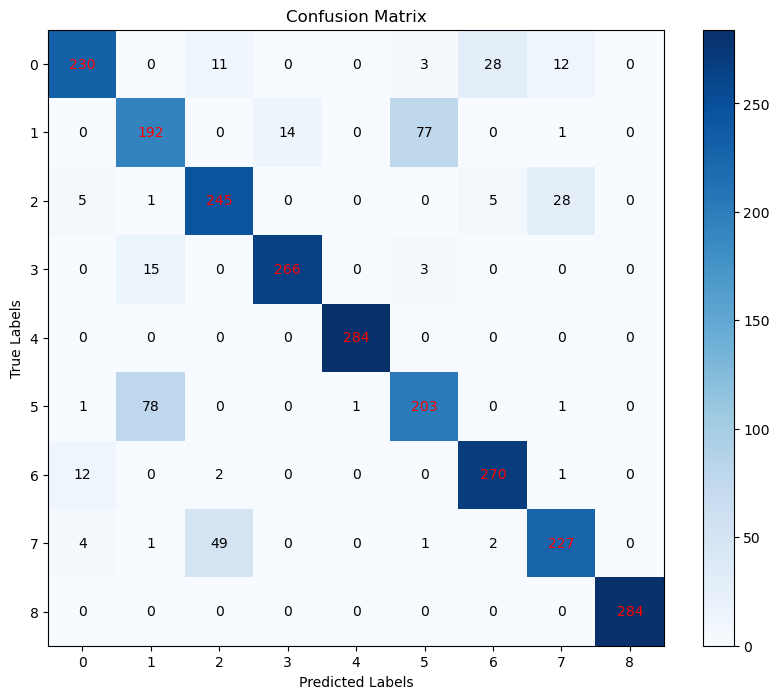

In [227]:
#-----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Example: y_test_blnc and y_pred_blnc are the true and predicted labels
conf_matrix = confusion_matrix(y_test_blnc, y_pred_blnc)

# Plot the confusion matrix using plt
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

# Add annotations
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]),
                 horizontalalignment='center',
                 verticalalignment='center',
                 color='red' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black')

# Customize the plot
plt.xticks(np.arange(len(np.unique(y_test_blnc))), np.unique(y_test_blnc))
plt.yticks(np.arange(len(np.unique(y_test_blnc))), np.unique(y_test_blnc))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Problem 2 : Linear Regresssion

### Exploratory data analysis.

In [15]:
#-----
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [3]:
# Load the data
chlorophyll_data = np.load('landis_chlorophyl_regression.npy')
chlorophyll_gt = np.load('landis_chlorophyl_regression_gt.npy')

In [4]:
# Understanding the data
print("Shape of chlorophyll_data (spectral bands):", chlorophyll_data.shape)
print("Shape of chlorophyll_gt (chlorophyll content):", chlorophyll_gt.shape)

print("Missing values in chlorophyll_data:", np.isnan(chlorophyll_data).sum())
print("Missing values in chlorophyll_gt:", np.isnan(chlorophyll_gt).sum())

print("Summary statistics for chlorophyll content:")
print("Mean:", np.mean(chlorophyll_gt))
print("Median:", np.median(chlorophyll_gt))
print("Standard Deviation:", np.std(chlorophyll_gt))
print("Min:", np.min(chlorophyll_gt))
print("Max:", np.max(chlorophyll_gt))

Shape of chlorophyll_data (spectral bands): (1000, 10)
Shape of chlorophyll_gt (chlorophyll content): (1000,)
Missing values in chlorophyll_data: 0
Missing values in chlorophyll_gt: 0
Summary statistics for chlorophyll content:
Mean: 40.42283372218778
Median: 40.54231917874818
Standard Deviation: 22.66210493530633
Min: 1.0502608279721377
Max: 79.84666034713156


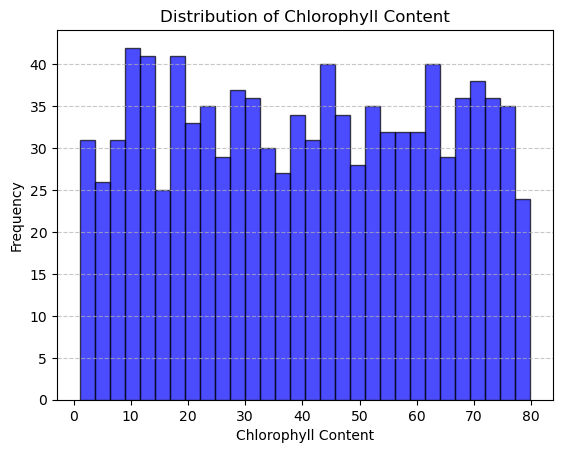

In [5]:
# Plot histogram of chlorophyll content
plt.hist(chlorophyll_gt, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Chlorophyll Content")
plt.xlabel("Chlorophyll Content")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

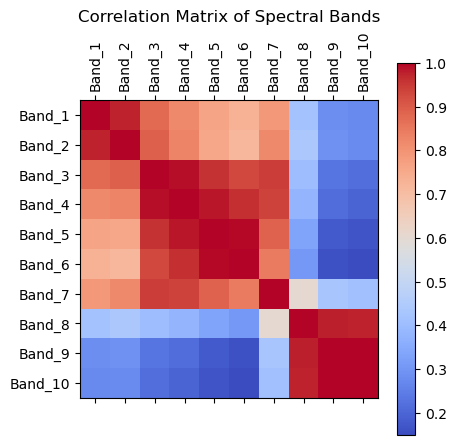

In [6]:
# Compute correlation matrix
correlation_matrix = np.corrcoef(chlorophyll_data, rowvar=False)

# Plot correlation matrix
plt.matshow(correlation_matrix, cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Matrix of Spectral Bands")
plt.xticks(range(10), [f"Band_{i+1}" for i in range(10)], rotation=90)
plt.yticks(range(10), [f"Band_{i+1}" for i in range(10)])
plt.show()

### Comments 2a.:


Here, in the problem, the goal is to predict chlorophyll content in leaves using spectral band data. It is a regression task where input features are the spectral band values (10 bands) and output (target) is the chlorophyll content. So, initially the statistics of the data was analyzed. It seems like there are no missing values in the data that could bias the distribution. Analyzing the correlation among bands, multicollinearity was observed. Multicollinearity is a situation in which multiple independent variables in a regression model are highly correlated with each other. Bands 1-2, 3-7, 8-10 seems to have very high correlation with each other. Multicollinearity in models like linear regression acna be problematic because it can lead to unstable regression coefficients. It means it makes hard to determine true impact of each independent variable on the dependent variable. So, we can either go with techniques like PCA or take a subset of bands. The distribution of the ground truth is almost evenly spread out, so it won't affect much in our model.




### Linear regression

Training set shape: (800, 10) (800,)
Testing set shape: (200, 10) (200,)


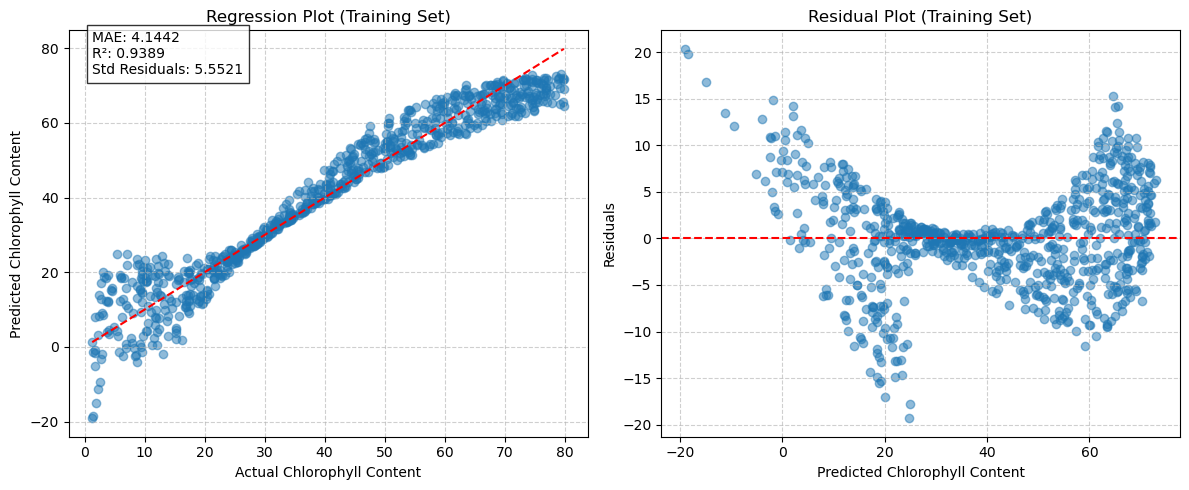

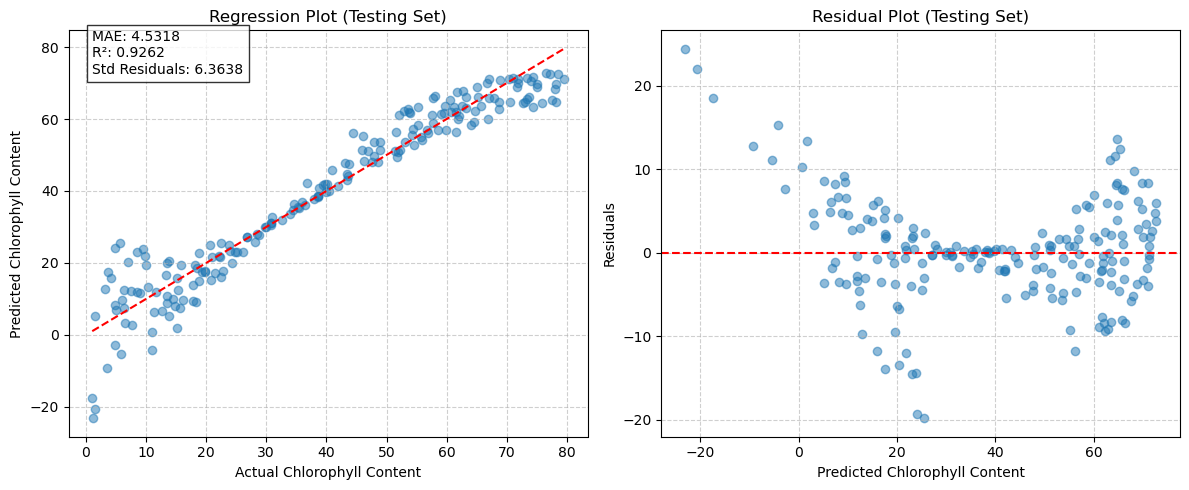

In [16]:
# Standardize the data
scaler = StandardScaler()
chlorophyll_data_std = scaler.fit_transform(chlorophyll_data)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    chlorophyll_data_std, chlorophyll_gt, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute metrics for training set
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
residuals_train = y_train - y_train_pred
std_residuals_train = np.std(residuals_train)

# Compute metrics for testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
residuals_test = y_test - y_test_pred
std_residuals_test = np.std(residuals_test)

# Regression plot for training set
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')
plt.title("Regression Plot (Training Set)")
plt.xlabel("Actual Chlorophyll Content")
plt.ylabel("Predicted Chlorophyll Content")
plt.grid(linestyle='--', alpha=0.6)
plt.text(min(y_train), max(y_train_pred) - 0.1,
         f"MAE: {mae_train:.4f}\nR²: {r2_train:.4f}\nStd Residuals: {std_residuals_train:.4f}",
         fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))

# Residual plot for training set
plt.subplot(1, 2, 2)
plt.scatter(y_train_pred, residuals_train, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot (Training Set)")
plt.xlabel("Predicted Chlorophyll Content")
plt.ylabel("Residuals")
plt.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Regression plot for testing set
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Regression Plot (Testing Set)")
plt.xlabel("Actual Chlorophyll Content")
plt.ylabel("Predicted Chlorophyll Content")
plt.grid(linestyle='--', alpha=0.6)
plt.text(min(y_test), max(y_test_pred) - 0.1,
         f"MAE: {mae_test:.4f}\nR²: {r2_test:.4f}\nStd Residuals: {std_residuals_test:.4f}",
         fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))

# Residual plot for testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, residuals_test, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot (Testing Set)")
plt.xlabel("Predicted Chlorophyll Content")
plt.ylabel("Residuals")
plt.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Comments 2b :


### Partial Least Square Regression


In [22]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

# Initialize lists to store results
n_components = list(range(1, 11))
train_r2_scores = []

# Perform PLSR for each number of components
for n in n_components:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)

    # Predict on training set
    y_train_pred = pls.predict(X_train)

    # Compute R² for training set
    train_r2 = r2_score(y_train, y_train_pred)
    train_r2_scores.append(train_r2)

    print(f"Components: {n}, Training R²: {train_r2:.4f}")

# Identify the best number of components
best_n = n_components[np.argmax(train_r2_scores)]
print(f"\nBest number of components: {best_n}")

Components: 1, Training R²: 0.6561
Components: 2, Training R²: 0.7124
Components: 3, Training R²: 0.9091
Components: 4, Training R²: 0.9114
Components: 5, Training R²: 0.9179
Components: 6, Training R²: 0.9194
Components: 7, Training R²: 0.9291
Components: 8, Training R²: 0.9384
Components: 9, Training R²: 0.9388
Components: 10, Training R²: 0.9389

Best number of components: 10


Training Set Metrics:
MAE: 4.1442, R²: 0.9389, Std Residuals: 5.5521

Testing Set Metrics:
MAE: 4.5318, R²: 0.9262, Std Residuals: 6.3638


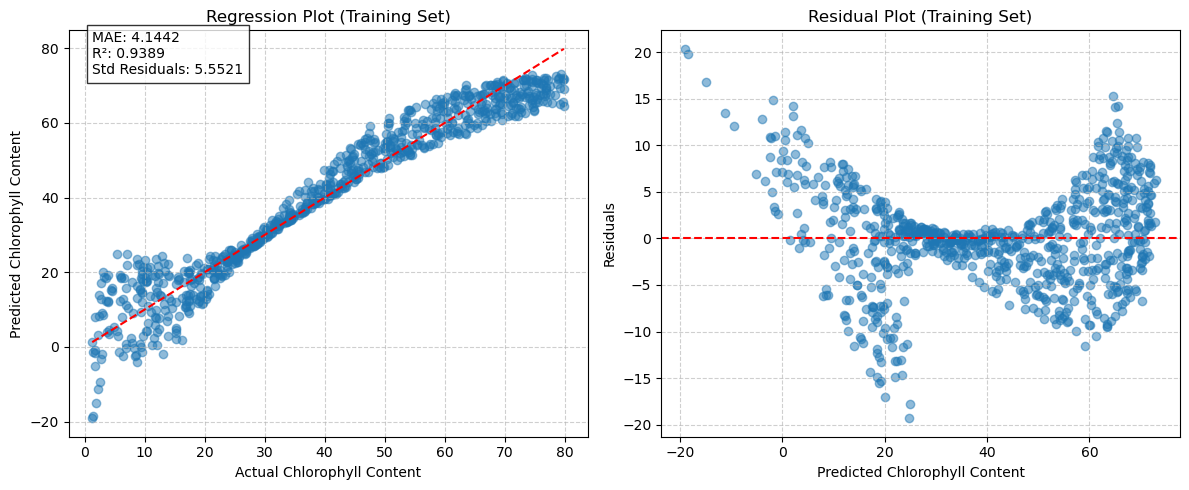

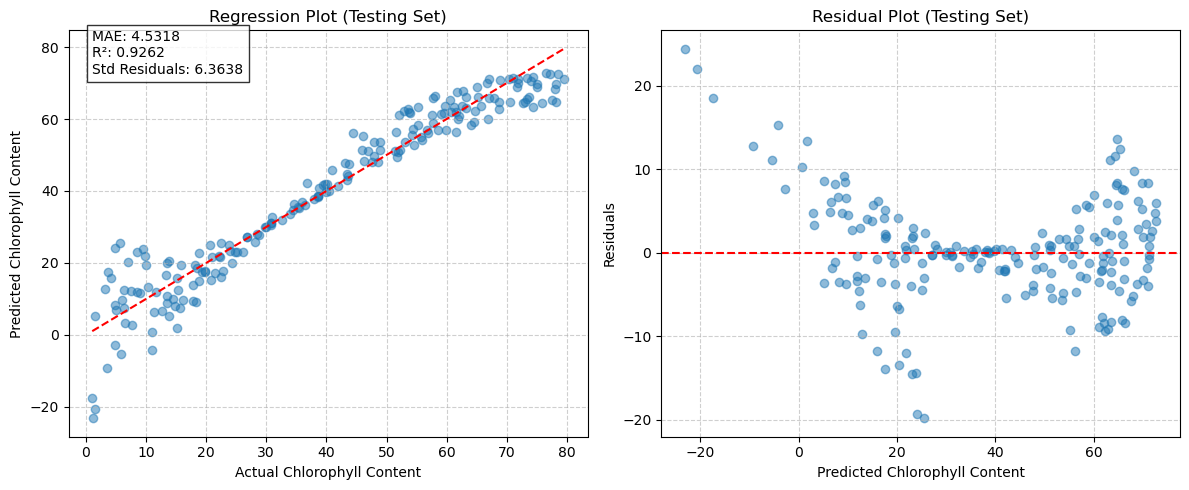

In [23]:
# Train PLSR with the best number of components

pls_best = PLSRegression(n_components=best_n)
pls_best.fit(X_train, y_train)

# Predict on training and testing sets
y_train_pred = pls_best.predict(X_train)
y_test_pred = pls_best.predict(X_test)

# Compute metrics for training set
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
residuals_train = y_train - y_train_pred.flatten()
std_residuals_train = np.std(residuals_train)

# Compute metrics for testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
residuals_test = y_test - y_test_pred.flatten()
std_residuals_test = np.std(residuals_test)

# Print metrics
print("Training Set Metrics:")
print(f"MAE: {mae_train:.4f}, R²: {r2_train:.4f}, Std Residuals: {std_residuals_train:.4f}")

print("\nTesting Set Metrics:")
print(f"MAE: {mae_test:.4f}, R²: {r2_test:.4f}, Std Residuals: {std_residuals_test:.4f}")

# Regression plot for training set
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')
plt.title("Regression Plot (Training Set)")
plt.xlabel("Actual Chlorophyll Content")
plt.ylabel("Predicted Chlorophyll Content")
plt.grid(linestyle='--', alpha=0.6)
plt.text(min(y_train), max(y_train_pred) - 0.1,
         f"MAE: {mae_train:.4f}\nR²: {r2_train:.4f}\nStd Residuals: {std_residuals_train:.4f}",
         fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))

# Residual plot for training set
plt.subplot(1, 2, 2)
plt.scatter(y_train_pred, residuals_train, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot (Training Set)")
plt.xlabel("Predicted Chlorophyll Content")
plt.ylabel("Residuals")
plt.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Regression plot for testing set
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Regression Plot (Testing Set)")
plt.xlabel("Actual Chlorophyll Content")
plt.ylabel("Predicted Chlorophyll Content")
plt.grid(linestyle='--', alpha=0.6)
plt.text(min(y_test), max(y_test_pred) - 0.1,
         f"MAE: {mae_test:.4f}\nR²: {r2_test:.4f}\nStd Residuals: {std_residuals_test:.4f}",
         fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8))

# Residual plot for testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, residuals_test, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot (Testing Set)")
plt.xlabel("Predicted Chlorophyll Content")
plt.ylabel("Residuals")
plt.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Comments 2c:


### MultiLayer Perceptron

In [27]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define the number of hidden layers to test
n_layers = range(1, 6)

# Initialize lists to store results
train_r2_scores = []
test_r2_scores = []

# Train MLP models with varying layers
for n in n_layers:
    # Create MLP model with n hidden layers (100 neurons per layer)
    mlp = MLPRegressor(
        hidden_layer_sizes=[10] * n,  # n hidden layers with 10 neurons each
        activation='relu',             # ReLU activation function
        max_iter=1000,                 # Maximum number of iterations
        random_state=42                # For reproducibility
    )

    # Train the model
    mlp.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = mlp.predict(X_train)
    y_test_pred = mlp.predict(X_test)

    # Compute R² for training and testing sets
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

    print(f"Number of Layers: {n}, Training R²: {train_r2:.4f}, Testing R²: {test_r2:.4f}")

# Identify the best number of layers
best_n = n_layers[np.argmax(test_r2_scores)]
print(f"\nBest number of layers: {best_n}")

C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Number of Layers: 1, Training R²: 0.9432, Testing R²: 0.9458


C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Number of Layers: 2, Training R²: 0.9903, Testing R²: 0.9900


C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Number of Layers: 3, Training R²: 0.9980, Testing R²: 0.9974
Number of Layers: 4, Training R²: 0.9991, Testing R²: 0.9991
Number of Layers: 5, Training R²: 0.9993, Testing R²: 0.9991

Best number of layers: 5


C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Number of Layers: 1


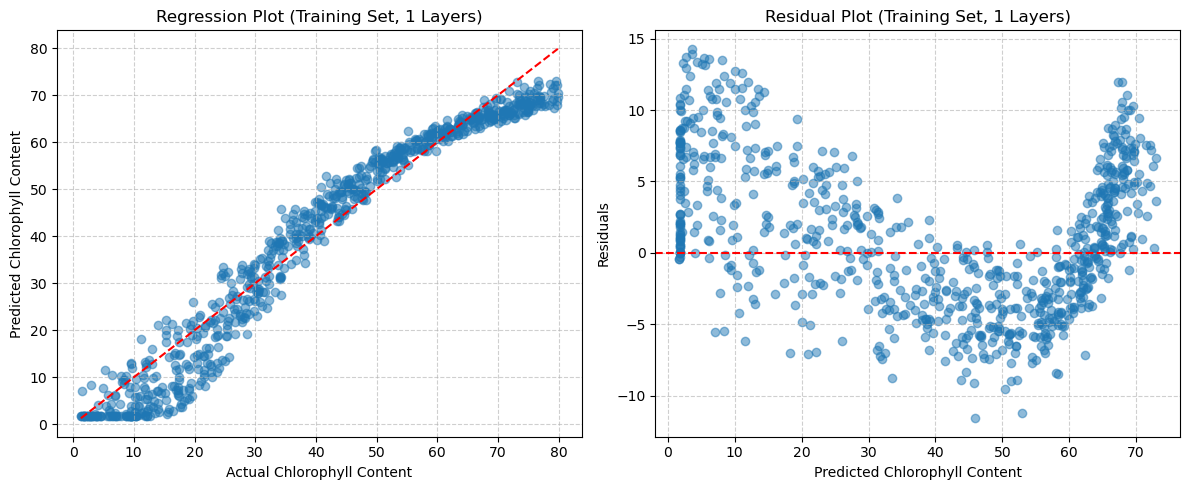

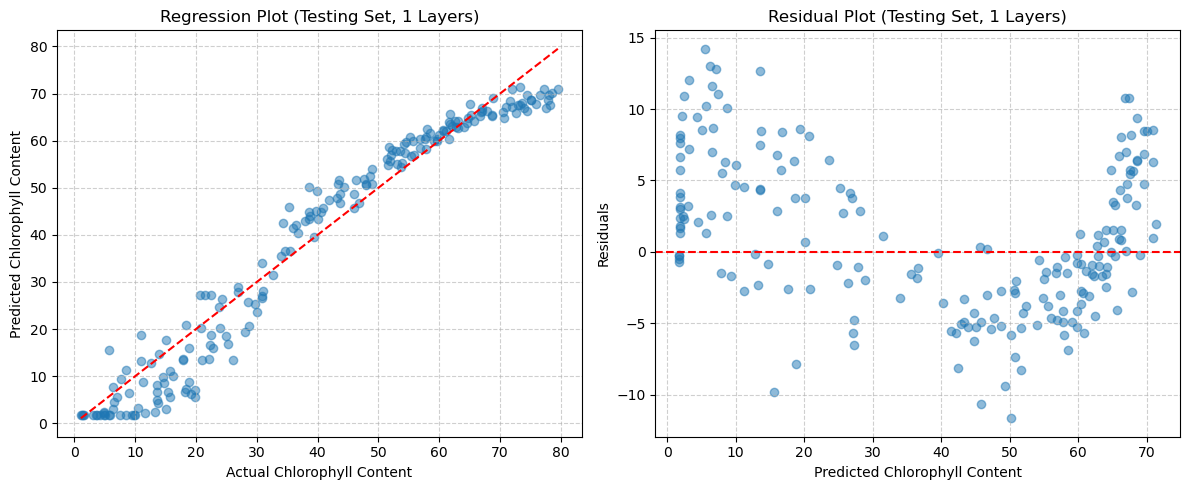

C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Number of Layers: 2


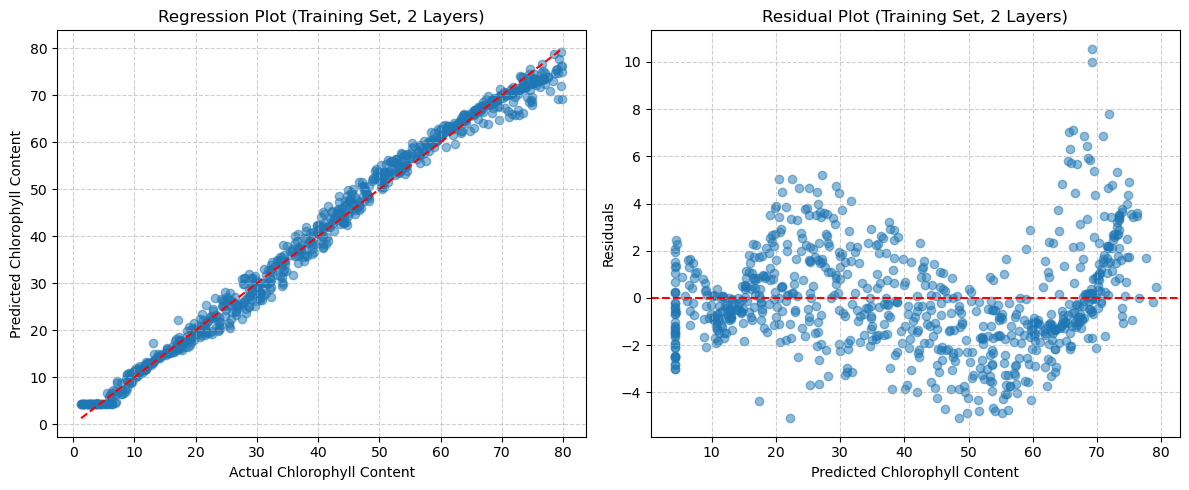

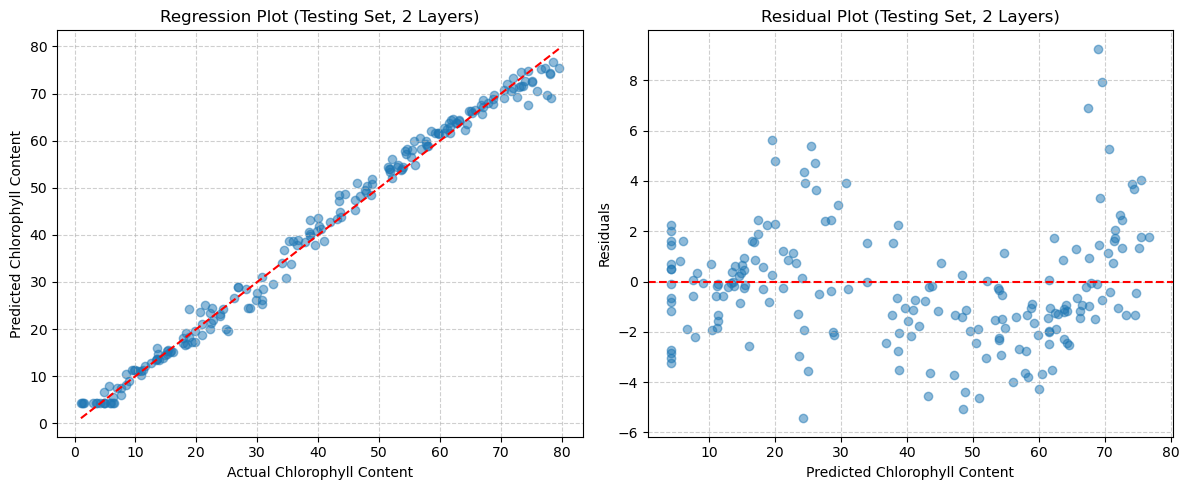

C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Number of Layers: 3


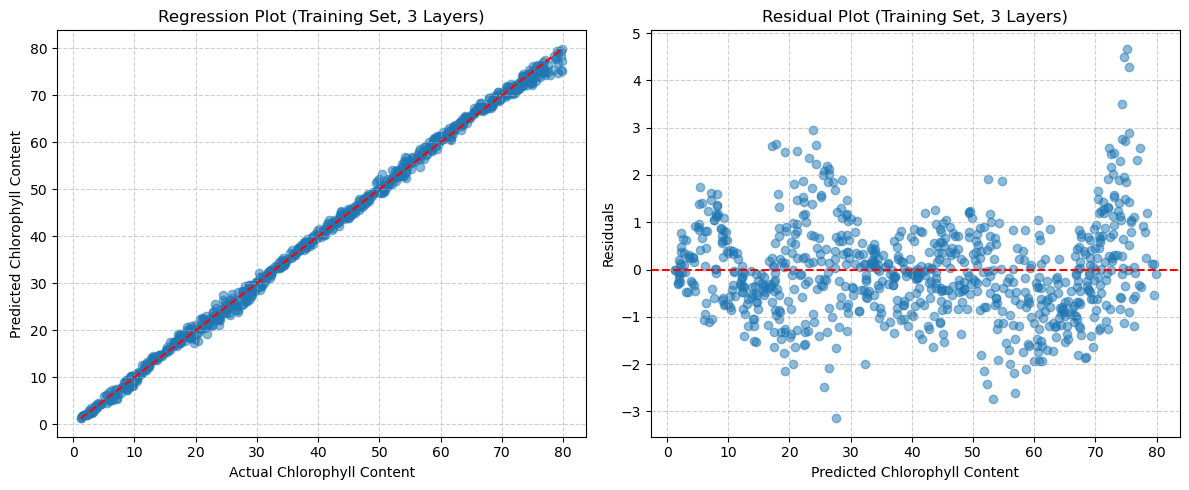

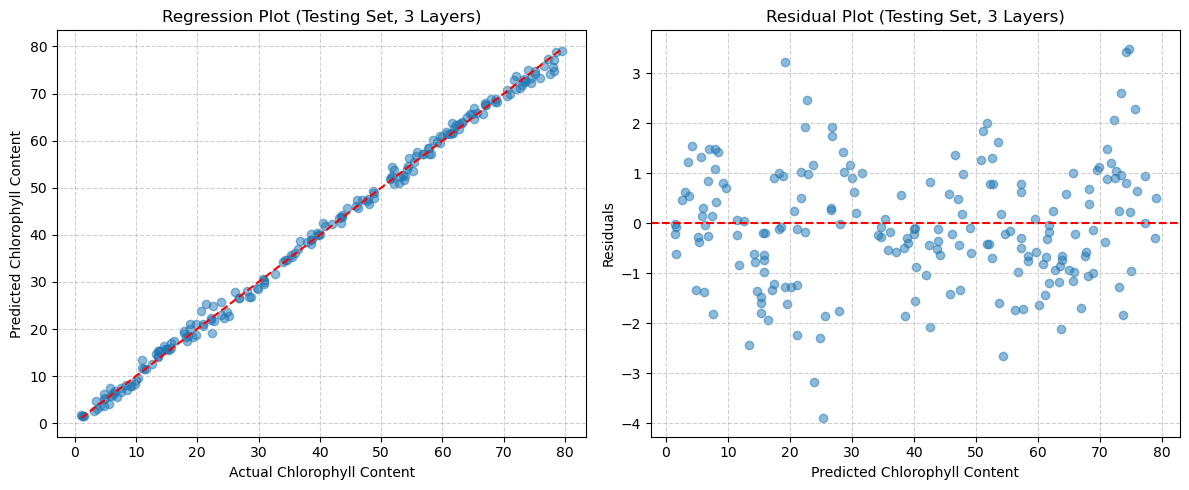


Number of Layers: 4


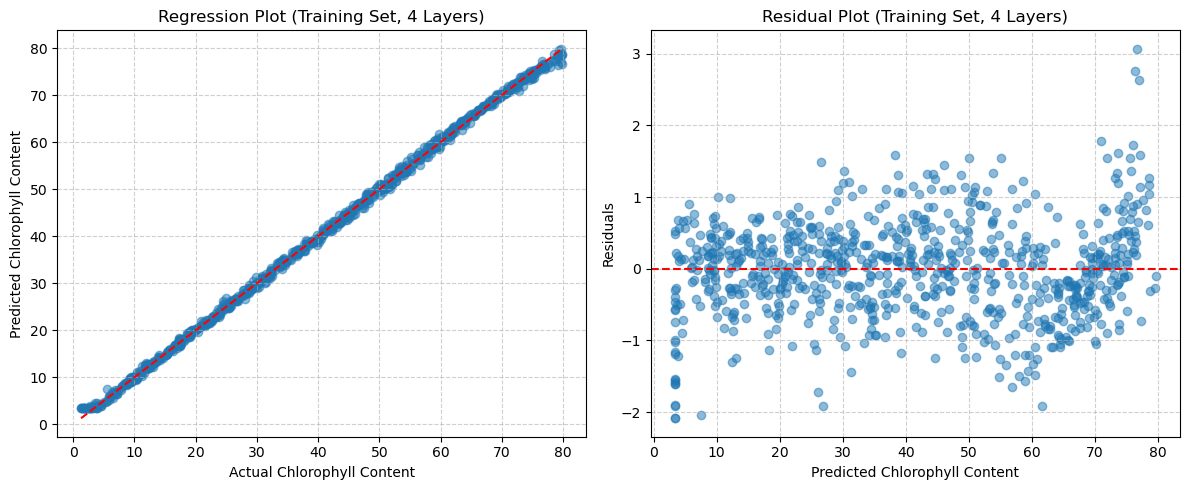

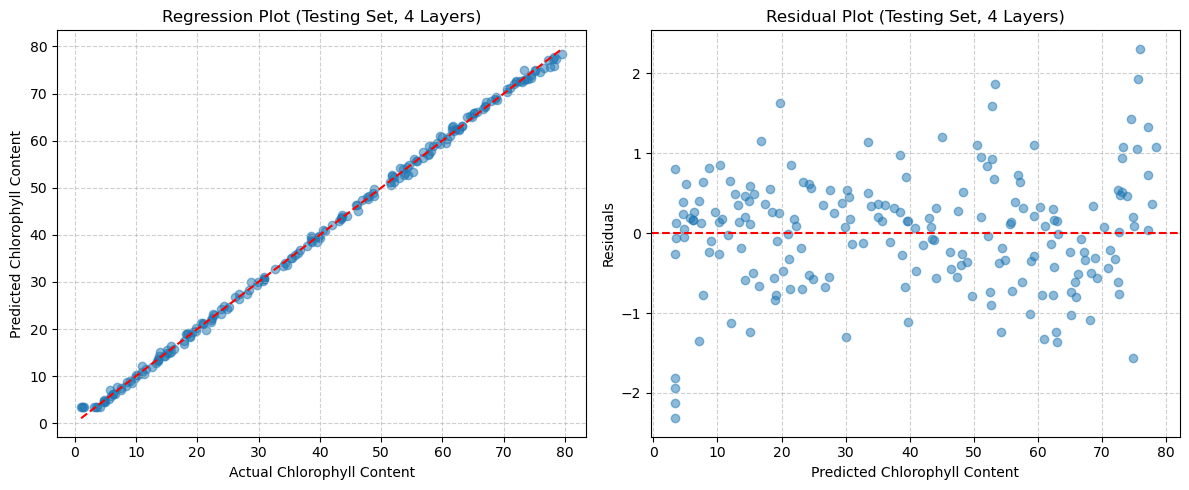


Number of Layers: 5


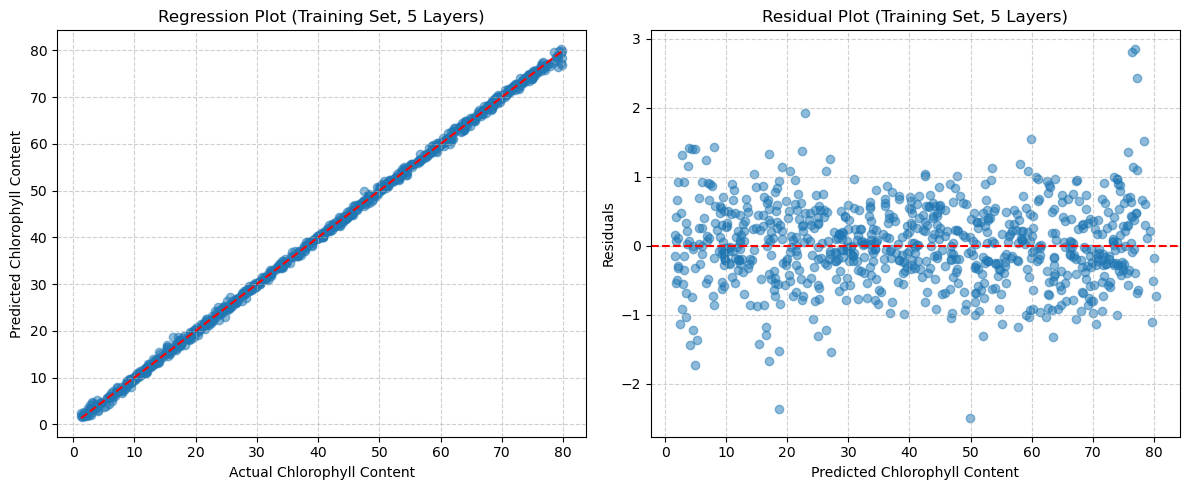

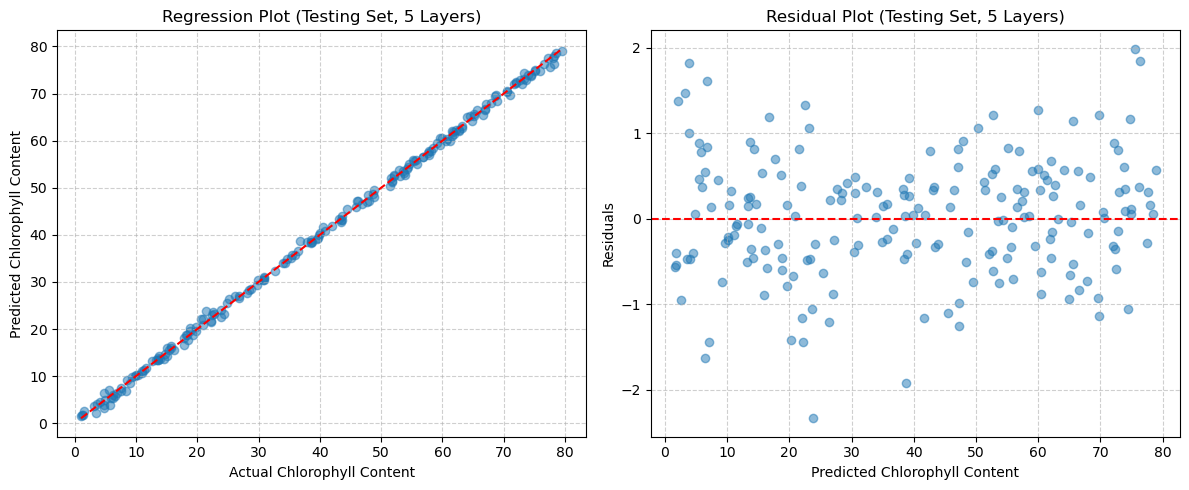

In [28]:
# Function to generate regression and residual plots
def generate_plots(y_true, y_pred, title):
    residuals = y_true - y_pred

    # Regression plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--')
    plt.title(f"Regression Plot ({title})")
    plt.xlabel("Actual Chlorophyll Content")
    plt.ylabel("Predicted Chlorophyll Content")
    plt.grid(linestyle='--', alpha=0.6)

    # Residual plot
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f"Residual Plot ({title})")
    plt.xlabel("Predicted Chlorophyll Content")
    plt.ylabel("Residuals")
    plt.grid(linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Generate plots for each MLP model
for n in n_layers:
    mlp = MLPRegressor(
        hidden_layer_sizes=[10] * n,
        activation='relu',
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X_train, y_train)

    y_train_pred = mlp.predict(X_train)
    y_test_pred = mlp.predict(X_test)

    print(f"\nNumber of Layers: {n}")
    generate_plots(y_train, y_train_pred, f"Training Set, {n} Layers")
    generate_plots(y_test, y_test_pred, f"Testing Set, {n} Layers")

C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Number of Layers: 1
Training Set Metrics:
MAE: 4.3544, R²: 0.9432, Std Residuals: 5.2357
Testing Set Metrics:
MAE: 4.4323, R²: 0.9458, Std Residuals: 5.3509


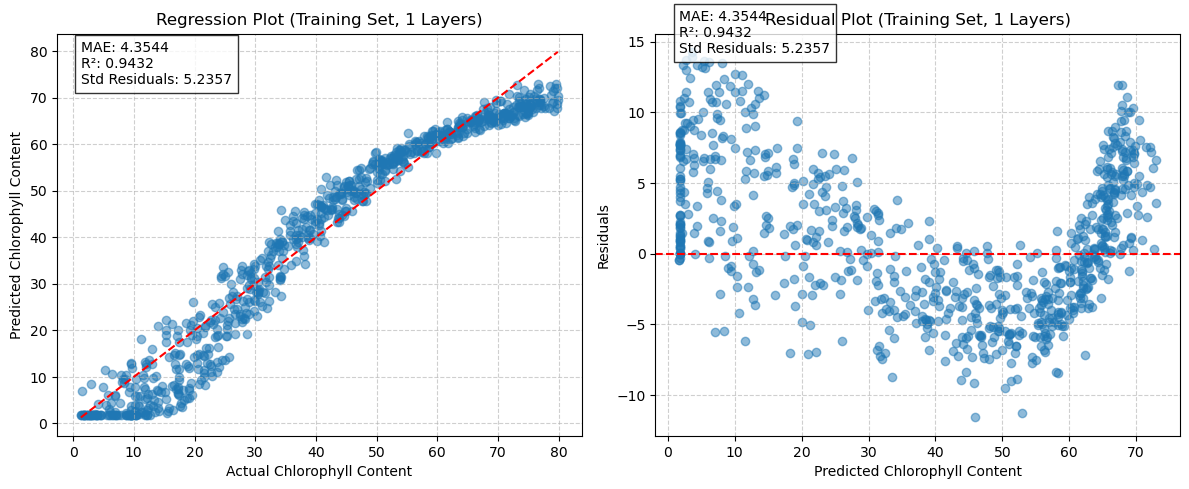

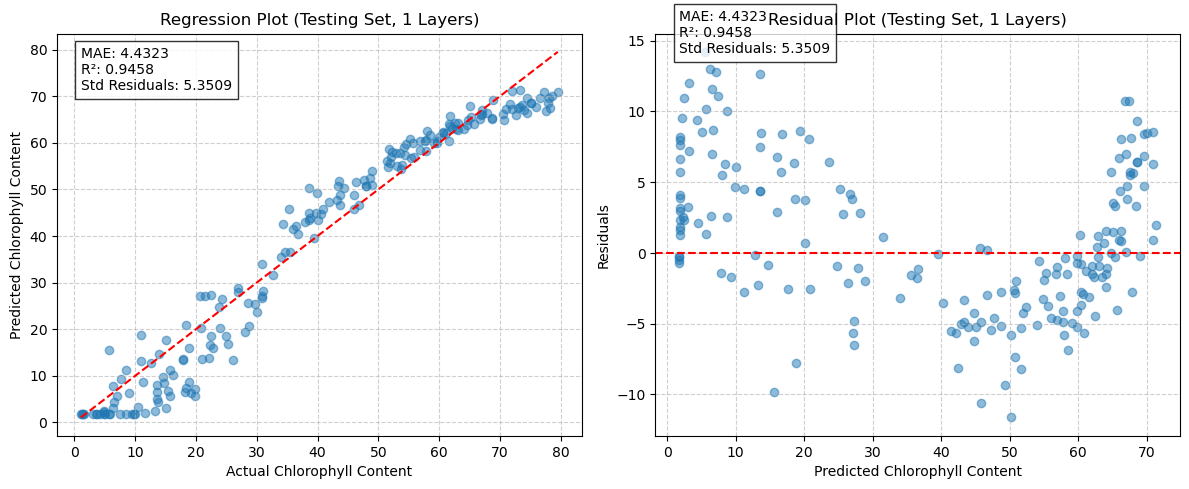

C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Number of Layers: 2
Training Set Metrics:
MAE: 1.6920, R²: 0.9903, Std Residuals: 2.2079
Testing Set Metrics:
MAE: 1.7962, R²: 0.9900, Std Residuals: 2.3332


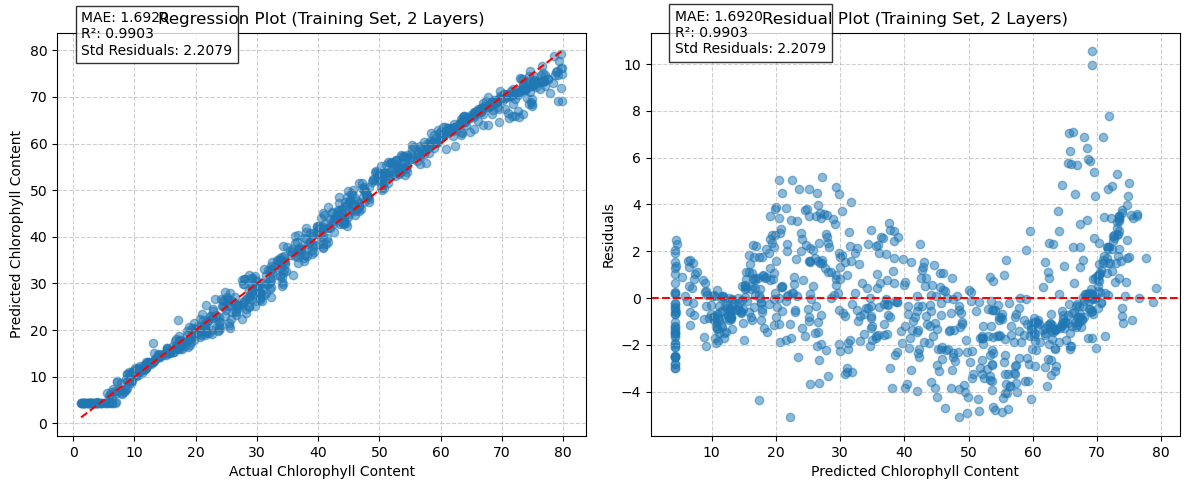

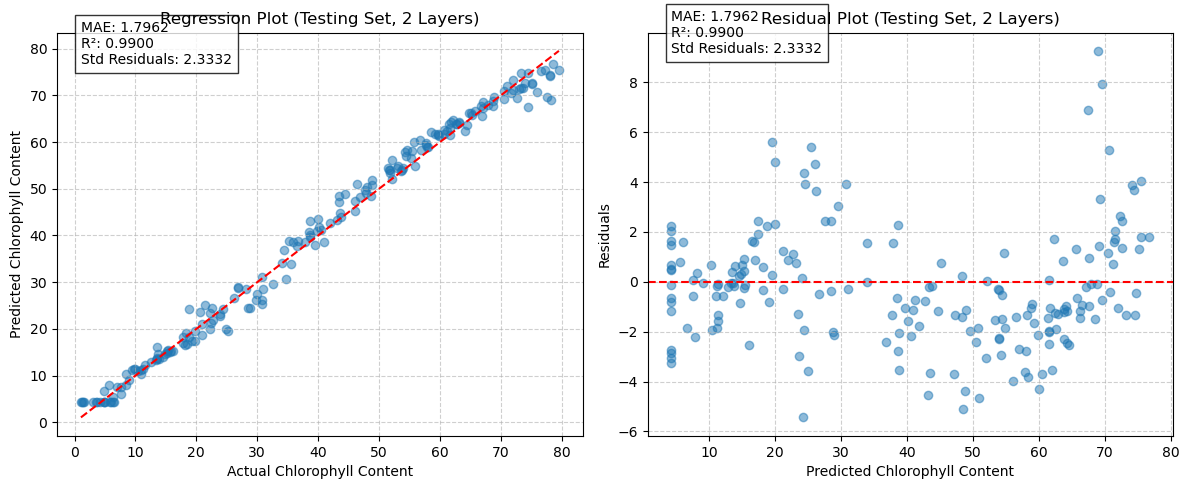

C:\Users\Usuario\anaconda3\envs\IMGS_IMGS_689_Graduate_Special_Topics\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Number of Layers: 3
Training Set Metrics:
MAE: 0.7647, R²: 0.9980, Std Residuals: 1.0010
Testing Set Metrics:
MAE: 0.9353, R²: 0.9974, Std Residuals: 1.1878


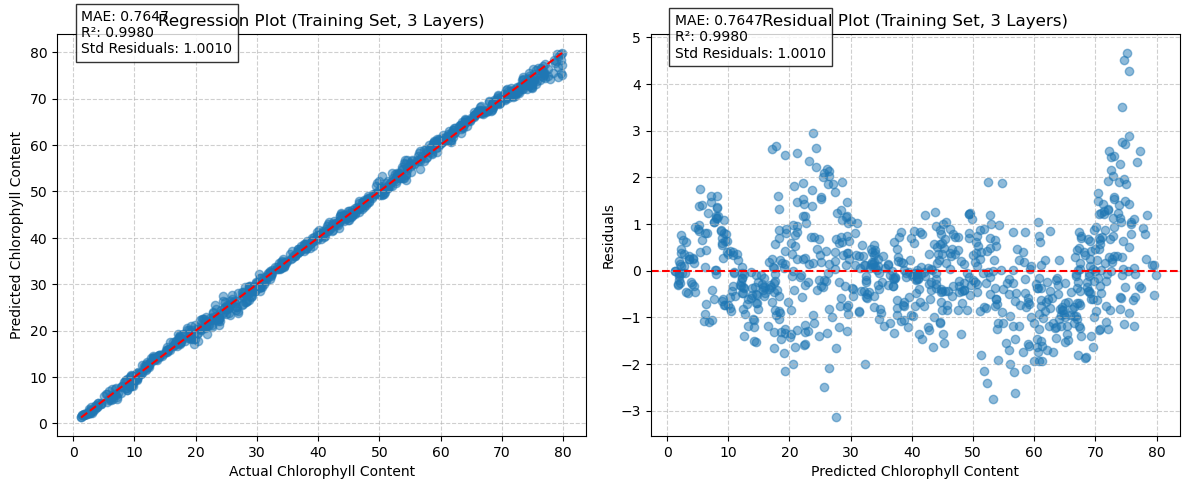

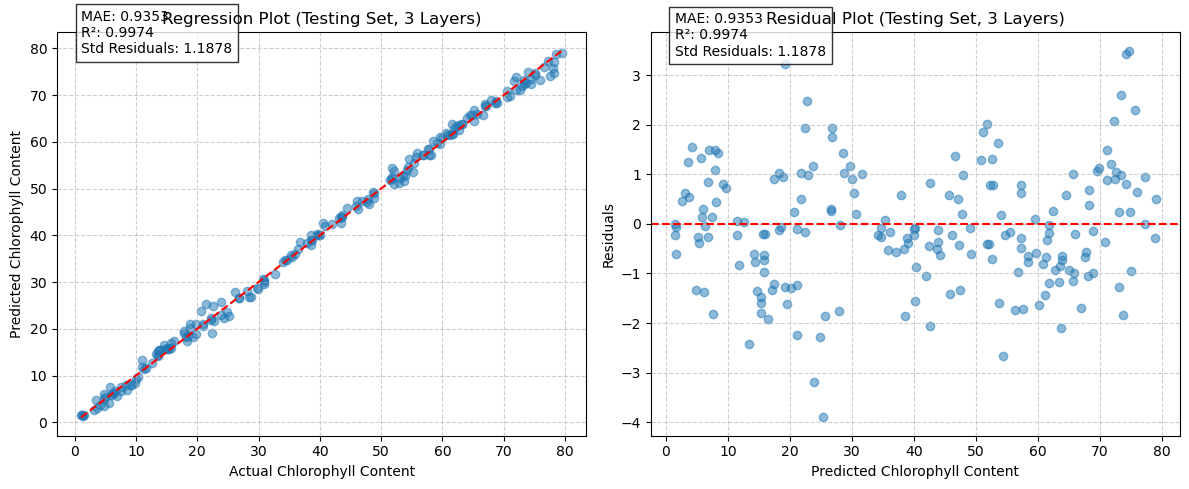


Number of Layers: 4
Training Set Metrics:
MAE: 0.5187, R²: 0.9991, Std Residuals: 0.6714
Testing Set Metrics:
MAE: 0.5540, R²: 0.9991, Std Residuals: 0.7225


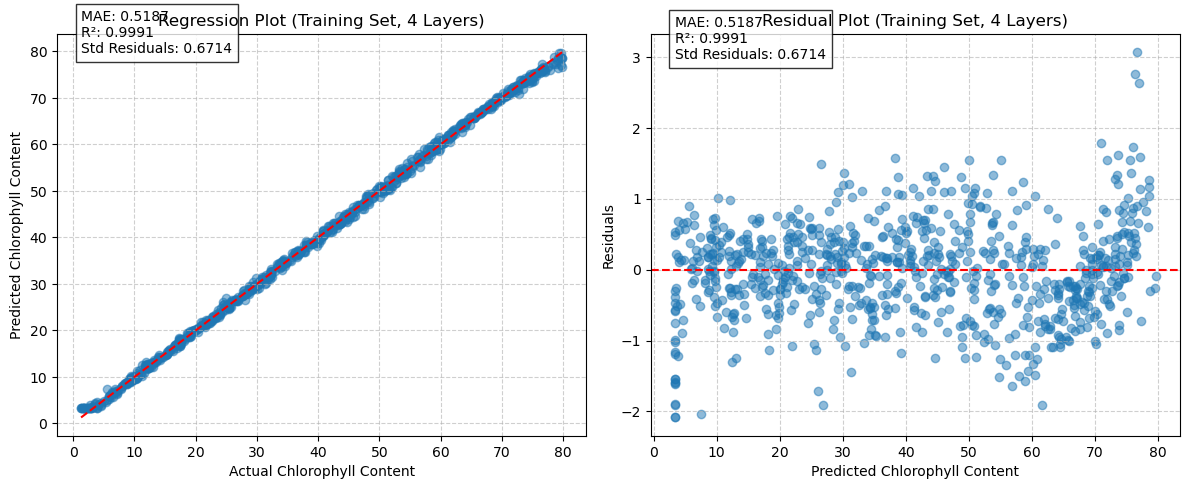

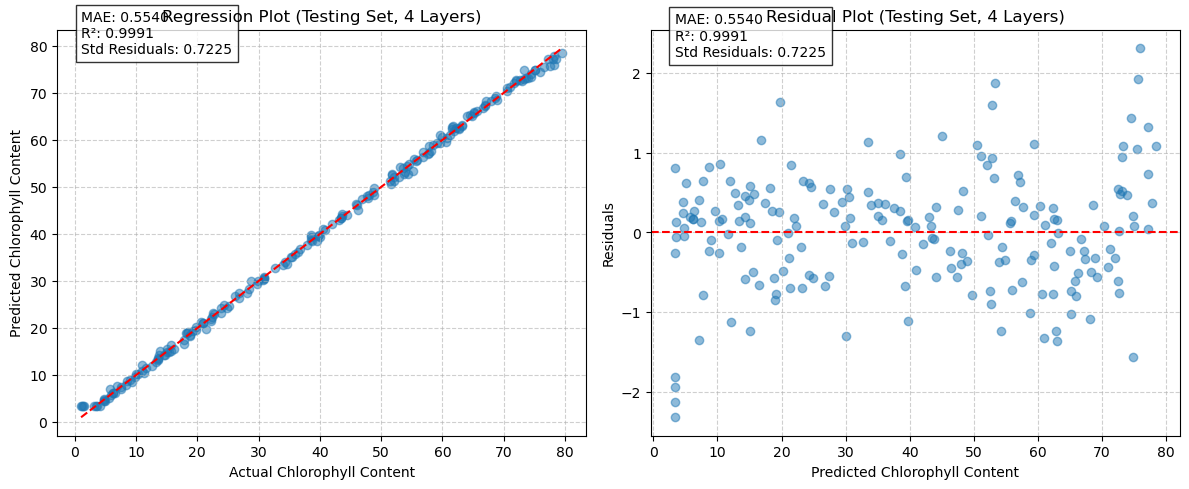


Number of Layers: 5
Training Set Metrics:
MAE: 0.4495, R²: 0.9993, Std Residuals: 0.5879
Testing Set Metrics:
MAE: 0.5474, R²: 0.9991, Std Residuals: 0.6995


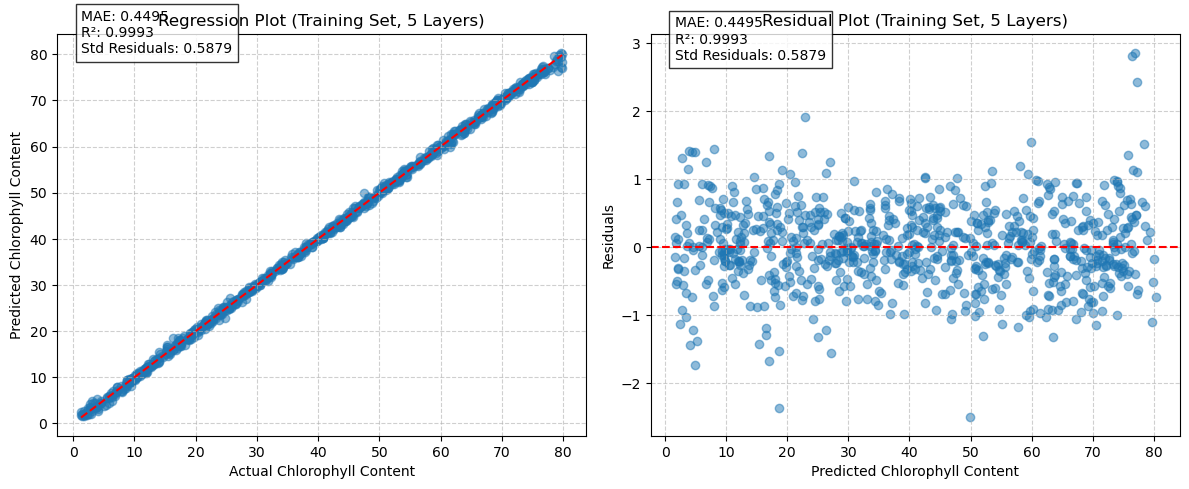

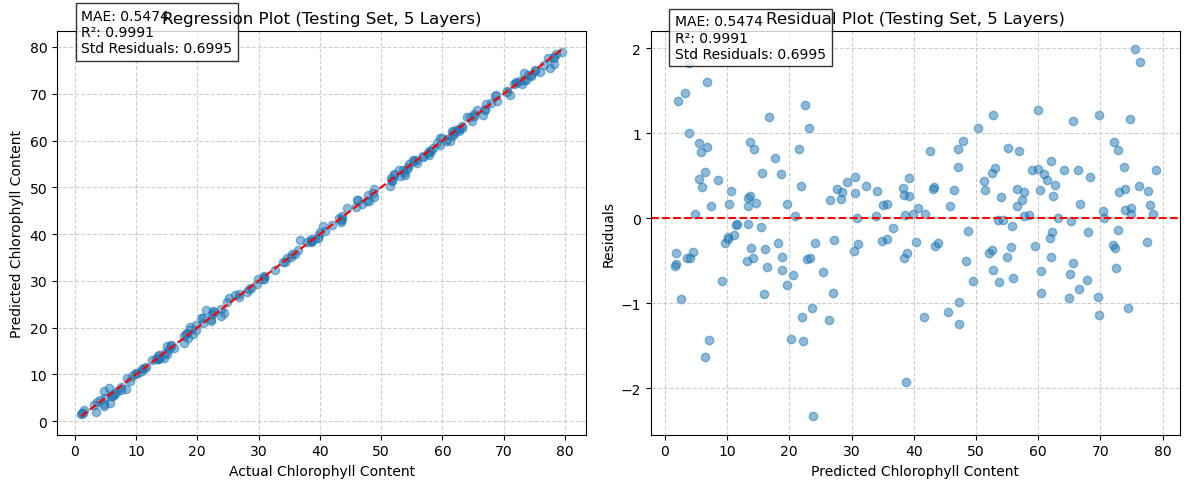

In [29]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Function to generate regression and residual plots with metrics
def generate_plots(y_true, y_pred, title):
    residuals = y_true - y_pred

    # Compute metrics
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    std_residuals = np.std(residuals)

    # Regression plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--')
    plt.title(f"Regression Plot ({title})")
    plt.xlabel("Actual Chlorophyll Content")
    plt.ylabel("Predicted Chlorophyll Content")
    plt.grid(linestyle='--', alpha=0.6)

    # Add metrics as text on the regression plot
    plt.text(
        min(y_true), max(y_pred) - 0.1,
        f"MAE: {mae:.4f}\nR²: {r2:.4f}\nStd Residuals: {std_residuals:.4f}",
        fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8)
    )

    # Residual plot
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f"Residual Plot ({title})")
    plt.xlabel("Predicted Chlorophyll Content")
    plt.ylabel("Residuals")
    plt.grid(linestyle='--', alpha=0.6)

    # Add metrics as text on the residual plot
    plt.text(
        min(y_pred), max(residuals) - 0.1,
        f"MAE: {mae:.4f}\nR²: {r2:.4f}\nStd Residuals: {std_residuals:.4f}",
        fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.8)
    )

    plt.tight_layout()
    plt.show()

# Generate plots for each MLP model
for n in n_layers:
    mlp = MLPRegressor(
        hidden_layer_sizes=[10] * n,  # 10 neurons per layer
        activation='relu',
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = mlp.predict(X_train)
    y_test_pred = mlp.predict(X_test)

    # Print metrics
    print(f"\nNumber of Layers: {n}")
    print("Training Set Metrics:")
    print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.4f}, R²: {r2_score(y_train, y_train_pred):.4f}, Std Residuals: {np.std(y_train - y_train_pred):.4f}")
    print("Testing Set Metrics:")
    print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}, R²: {r2_score(y_test, y_test_pred):.4f}, Std Residuals: {np.std(y_test - y_test_pred):.4f}")

    # Generate plots for training and testing sets
    generate_plots(y_train, y_train_pred, f"Training Set, {n} Layers")
    generate_plots(y_test, y_test_pred, f"Testing Set, {n} Layers")

### Comments 2d  :